In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Вводная часть

Считаем наш датасет

In [ ]:
bd = pd.read_excel("NetflixShows.xlsx")

Очистим датасет, удалив полностью идентичные строки

In [ ]:
bd[bd.columns[0]] = bd[bd.columns[0]].astype(str) # записываем все названия как строки, чтобы дальше можно было сортировать
counts = bd.value_counts(dropna=False).reset_index(name="count") # создаём новую таблицу, в которой остаются только уникальные строки, а в конце добавляется столбец count с количеством таких же строк в начальной таблице

Проверим тайтлы, в которых содержатся некорректные символы. Возможно, некорректные символы являются результатом неправильного форматирования данных с иностранных языков. А может, есть и вообще бредовые тайтлы. За корректные названия возьмем тайтлы, где встречаются буквы латиницы, цифры, дефис, апостроф, точка, запятая, вопросительный и восклицательный знаки, амперсанд, двоеточие, пробел и квадратные и круглые скобки.

In [ ]:
symbols_except_of_letters = "-'.,?!:()[]&0123456789 "
tmp_shows_with_misspellings = []
for i in netflix_shows_dataset['title']:
  flag = False
  for j in str(i):
    if j in symbols_except_of_letters or (65 <= ord(j) <= 90) or (97 <= ord(j) <= 122):
      continue
    else:
      flag = True
  if flag == True:
    tmp_shows_with_misspellings.append(i)
shows_with_misspellings = pd.Series(tmp_shows_with_misspellings)
shows_with_misspellings.head(100)

,0
0,"ÌÒ Pai, ÌÒ - Look at This"
1,OperaÌ¤Ìµes Especiais
2,O Amor no DivÌ£
3,MerlÌ?
4,Gabriel lglesias: I‰Ûªm Sorry For What I Said ...
5,MerlÌ?
6,PokÌ©mon: Indigo League
7,PokÌ©mon: XY
8,PokÌ©mon: Indigo League


В итоге у нас есть 7 тайтлов, где есть непонятные символы в названиях. Однако ручной ресерч показывает - такие тайтлы есть, и это не более, чем какая-то ошибка в форматировании, а следовательно можем не считать эти тайтлы выбросами.
Ссылки на тайтлы:
* [ÌÒ Pai, ÌÒ - Look at This](https://www.justwatch.com/br/filme/o-amor-no-diva)


* [OperaÌ¤Ìµes Especiais](https://www.imdb.com/title/tt0895777/)

* [O Amor no DivÌ£](https://www.kinopoisk.ru/film/988573/?utm_referrer=yandex.ru)


* [MerlÌ?](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%80%D0%BB%D0%B8_(%D1%82%D0%B5%D0%BB%D0%B5%D1%81%D0%B5%D1%80%D0%B8%D0%B0%D0%BB)

* [Gabriel lglesias: I‰Ûªm Sorry For What I Said ...](https://www.imdb.com/title/tt6302122/)

* [PokÌ©mon: Indigo League](https://en.wikipedia.org/wiki/Pok%C3%A9mon:_Indigo_League)

* [PokÌ©mon: XY](https://en.wikipedia.org/wiki/Pok%C3%A9mon_X_and_Y#:~:text=X%20and%20Y%20take%20place,of%20center%20is%20Lumiose%20City.)


Выведем все упомянутые рейтинги (соответствуют реальным рейтингам)

In [ ]:
rating_names = set(counts['rating'])
np.array(rating_names)

array({'TV-MA', 'TV-14', 'TV-Y7', 'TV-Y7-FV', 'G', 'TV-Y', 'PG-13', 'TV-PG', 'R', 'NR', 'UR', 'TV-G', 'PG'},
      dtype=object)

In [ ]:
rating_decription = counts[["rating", "ratingDescription"]].drop_duplicates().sort_values(by="ratingDescription")
print(rating_decription)

       rating  ratingDescription
21       TV-Y                 10
4           G                 35
26       TV-G                 35
62      TV-Y7                 41
6    TV-Y7-FV                 42
10         PG                 60
28      TV-PG                 70
135     PG-13                 80
1       TV-14                 90
111         R                100
0       TV-MA                110
79         NR                124
253        UR                124


Заметим, что G и TV-G кодируются одинаково, аналогично с NR и UR. Исходя из логики остальной кодировки, поменяем description, чтобы они не пересекались.

In [ ]:
counts.loc[(counts["rating"]=="TV-G") & (counts["ratingDescription"]==35), "ratingDescription"] = 38
counts.loc[(counts["rating"]=="UR") & (counts["ratingDescription"]==124), "ratingDescription"] = 130

rating_decription = counts[["rating", "ratingDescription"]].drop_duplicates().sort_values(by="ratingDescription")
print(rating_decription)

       rating  ratingDescription
21       TV-Y                 10
4           G                 35
26       TV-G                 38
62      TV-Y7                 41
6    TV-Y7-FV                 42
10         PG                 60
28      TV-PG                 70
135     PG-13                 80
1       TV-14                 90
111         R                100
0       TV-MA                110
79         NR                124
253        UR                130


Проверка на то, есть ли некорректные (слишком большие или слишком маленькие) года

In [ ]:
years_incorrect = counts[counts["release year"] > 2017]
years_incorrect = counts[counts["release year"] < 1888]

print(years_incorrect.size)

0


Некорректных годов нет

### Проанализируем, какие данные чаще всего дублировались

      rating  count  rating_occurrences      coef
0          G    138                  53  2.603774
1         NR     14                  10  1.400000
2         PG    170                  76  2.236842
3      PG-13     15                  12  1.250000
4          R     19                  14  1.357143
5      TV-14    234                 106  2.207547
6       TV-G     52                  29  1.793103
7      TV-MA    148                  82  1.804878
8      TV-PG     59                  33  1.787879
9       TV-Y     68                  36  1.888889
10     TV-Y7     38                  23  1.652174
11  TV-Y7-FV     44                  25  1.760000
12        UR      1                   1  1.000000


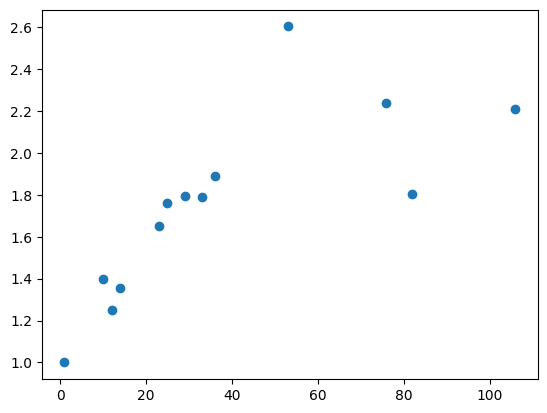

In [ ]:
rating_dupl_sum = counts.groupby("rating", dropna=False)["count"].sum().reset_index() # считаем, сколько раз в начальной таблице встречается каждый из возрастных рейтингов (с учётом повторов)
rating_dupl_sum["rating_occurrences"] = counts.groupby("rating", dropna=False)["rating"].count().values # считаем, сколько раз каждый из рейтингов встречается в таблице без повторов
rating_dupl_sum["coef"] = rating_dupl_sum["count"] / rating_dupl_sum["rating_occurrences"] # рассчитываем, во сколько раз больше встречаемость рейтинга в начальной таблице, чем в таблице без повторов
plt.scatter(rating_dupl_sum["rating_occurrences"], rating_dupl_sum["coef"])
print(rating_dupl_sum)

/tmp/ipython-input-3775790988.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


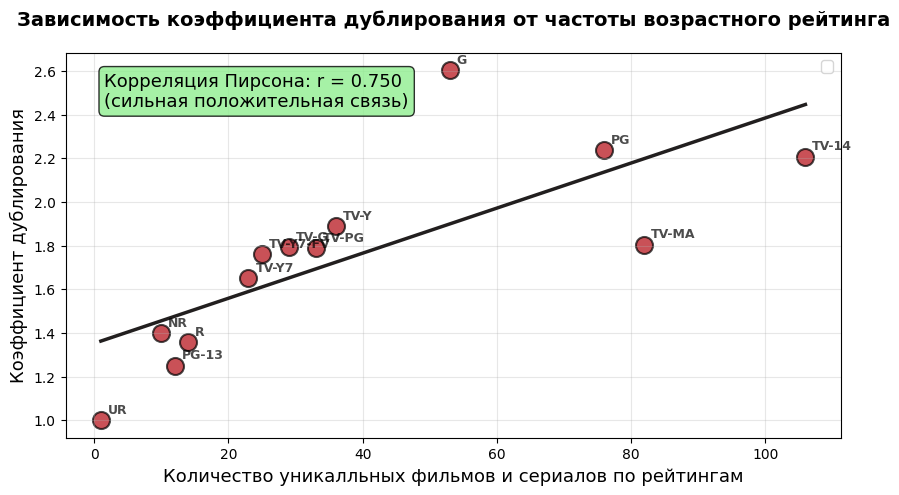

In [ ]:
# Рассчитываем корреляцию
correlation = rating_dupl_sum["rating_occurrences"].corr(rating_dupl_sum["coef"])

# Создаём график
fig, ax = plt.subplots(figsize=(10, 5))

# Scatter plot
ax.scatter(rating_dupl_sum["rating_occurrences"], rating_dupl_sum["coef"],
           alpha=0.7, s=150, color='#b20710', edgecolors='black', linewidth=1.5)

# Добавляем подписи рейтингов к точкам
for idx, row in rating_dupl_sum.iterrows():
    if pd.notna(row['rating']):  # Только для не-NaN значений
        ax.annotate(row['rating'],
                   (row['rating_occurrences'], row['coef']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, alpha=0.7, fontweight='bold')

# Линия тренда
x = rating_dupl_sum["rating_occurrences"].values
y = rating_dupl_sum["coef"].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
ax.plot(x_trend, p(x_trend), color='#221f1f', linewidth=2.5)

# Добавляем текст с корреляцией
ax.text(0.05, 0.95, f'Корреляция Пирсона: r = {correlation:.3f}\n(сильная положительная связь)',
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Оформление
ax.set_xlabel('Количество уникалльных фильмов и сериалов по рейтингам', fontsize=13)
ax.set_ylabel('Коэффициент дублирования', fontsize=13)
ax.set_title('Зависимость коэффициента дублирования от частоты возрастного рейтинга',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.show()

    release year  count  years_occurrences      coef
0           1940      3                  1  3.000000
1           1976      4                  1  4.000000
2           1978      2                  1  2.000000
3           1982      6                  2  3.000000
4           1986      4                  1  4.000000
5           1987      2                  1  2.000000
6           1989      2                  2  1.000000
7           1990      7                  2  3.500000
8           1991      5                  1  5.000000
9           1992      2                  1  2.000000
10          1993     14                  5  2.800000
11          1994      6                  4  1.500000
12          1995      6                  2  3.000000
13          1996      1                  1  1.000000
14          1997     28                  9  3.111111
15          1998     26                  9  2.888889
16          1999     19                  5  3.800000
17          2000     17                  7  2.

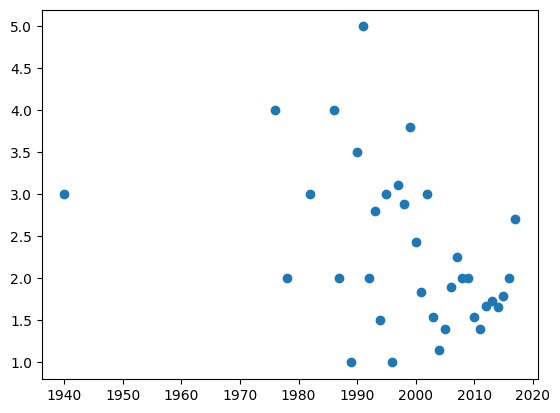

In [ ]:
years_dupl_sum = counts.groupby("release year", dropna=False)["count"].sum().reset_index() # считаем, сколько раз в начальной таблице встречается каждый из годов релиза (с учётом повторов)
years_dupl_sum["years_occurrences"] = counts.groupby("release year", dropna=False)["release year"].count().values # считаем, сколько раз каждый из годов встречается в таблице без повторов
years_dupl_sum["coef"] = years_dupl_sum["count"] / years_dupl_sum["years_occurrences"] # рассчитываем, во сколько раз больше встречаемость года в начальной таблице, чем в таблице без повторов
plt.scatter(years_dupl_sum["release year"], years_dupl_sum["coef"])
print(years_dupl_sum)

    user rating score  count  user_rating_occurrences      coef
0                55.0      2                        2  1.000000
1                56.0      6                        5  1.200000
2                57.0     12                        6  2.000000
3                58.0      6                        4  1.500000
4                59.0      1                        1  1.000000
5                61.0     15                        7  2.142857
6                62.0      9                        4  2.250000
7                63.0      4                        4  1.000000
8                64.0     10                        5  2.000000
9                65.0      5                        2  2.500000
10               66.0      5                        3  1.666667
11               67.0     10                        4  2.500000
12               68.0     12                        5  2.400000
13               69.0      5                        4  1.250000
14               70.0     11            

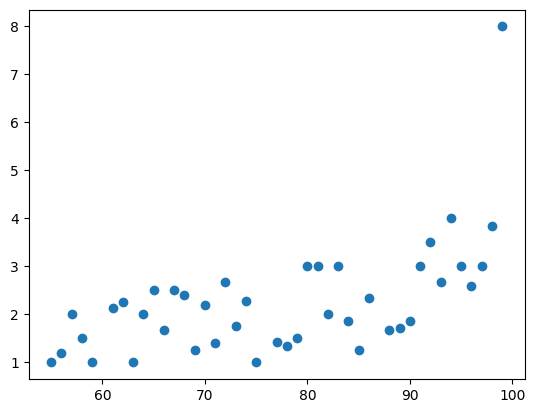

In [ ]:
rating_score_dupl_sum = counts.groupby("user rating score", dropna=False)["count"].sum().reset_index() # считаем, сколько раз в начальной таблице встречается каждый из рейтингов (с учётом повторов)
rating_score_dupl_sum["user_rating_occurrences"] = counts.groupby("user rating score", dropna=False)["user rating score"].count().values # считаем, сколько раз каждый из рейтингов встречается в таблице без повторов
rating_score_dupl_sum["coef"] = rating_score_dupl_sum["count"] / rating_score_dupl_sum["user_rating_occurrences"] # рассчитываем, во сколько раз больше встречаемость рейтинга в начальной таблице, чем в таблице без повторов
plt.scatter(rating_score_dupl_sum["user rating score"], rating_score_dupl_sum["coef"])
print(rating_score_dupl_sum)

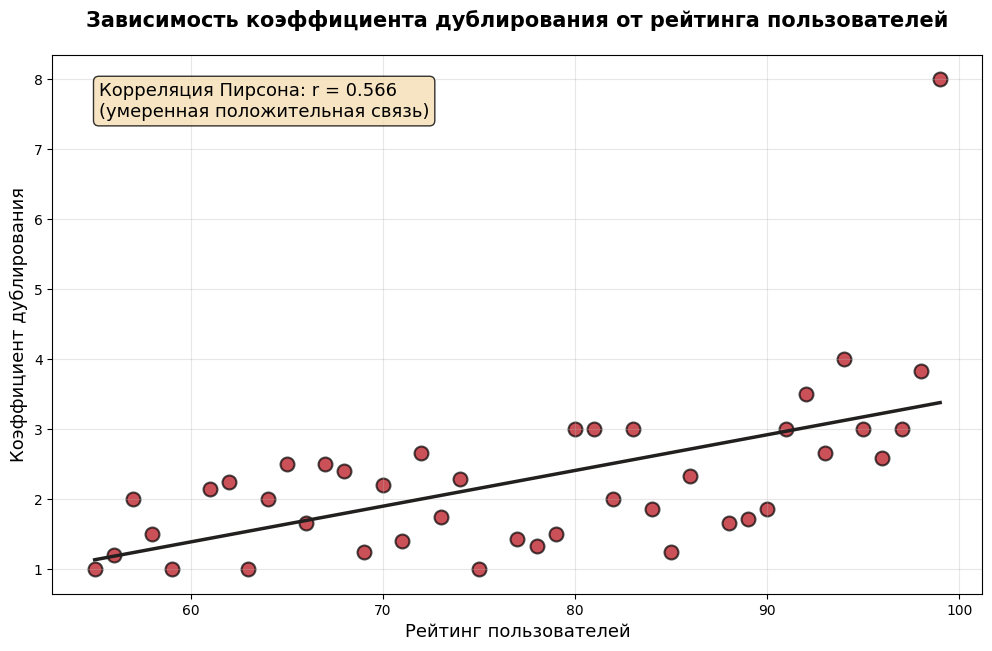

=== Топ-5 рейтингов с наибольшим дублированием ===
    user rating score  count  user_rating_occurrences      coef
41               99.0      8                        1  8.000000
36               94.0     32                        8  4.000000
40               98.0     46                       12  3.833333
34               92.0     28                        8  3.500000
23               80.0     21                        7  3.000000


In [ ]:
rating_score_dupl_sum = counts.groupby("user rating score", dropna=False)["count"].sum().reset_index()
rating_score_dupl_sum["user_rating_occurrences"] = counts.groupby("user rating score", dropna=False)["user rating score"].count().values
rating_score_dupl_sum["coef"] = rating_score_dupl_sum["count"] / rating_score_dupl_sum["user_rating_occurrences"]

# Убираем NaN и inf для корреляции
rating_clean = rating_score_dupl_sum[rating_score_dupl_sum["user rating score"].notna() &
                                      np.isfinite(rating_score_dupl_sum["coef"])].copy()

# Рассчитываем корреляцию
correlation = rating_score_dupl_sum["user rating score"].corr(rating_clean["coef"])

# Создаём график
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot - ИЗМЕНЁН цвет на #b20710
ax.scatter(rating_clean["user rating score"], rating_clean["coef"],
           alpha=0.7, s=100, color='#b20710', edgecolors='black', linewidth=1.5)

# Линия тренда - ИЗМЕНЁН цвет на #221f1f и УБРАН label
x = rating_clean["user rating score"].values
y = rating_clean["coef"].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
ax.plot(x_trend, p(x_trend), color='#221f1f', linewidth=2.5)

# Добавляем текст с корреляцией
ax.text(0.05, 0.95, f'Корреляция Пирсона: r = {correlation:.3f}\n(умеренная положительная связь)',
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Оформление - ИЗМЕНЁН текст xlabel
ax.set_xlabel('Рейтинг пользователей', fontsize=13)
ax.set_ylabel('Коэффициент дублирования', fontsize=13)
ax.set_title('Зависимость коэффициента дублирования от рейтинга пользователей',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
# УБРАН ax.legend() так как нет label у линии тренда

plt.show()

# Выводим таблицу
print("=== Топ-5 рейтингов с наибольшим дублированием ===")
print(rating_clean.nlargest(5, "coef")[["user rating score", "count", "user_rating_occurrences", "coef"]])

В случае с рейтингами прослеживается зависимость между популярностью (по количеству) рейтинга в начальной таблице и средним значением "дублирования". Чем популярнее рейтинг, тем чаще фильмы с таким рейтингом дублировались.

По годам никакой зависимости не прослеживается.

Также можно заметить, что чем более качественные (по оценкам) фильмы/шоу, тем чаще они дублируются.

Посмотрим на то, как соотносятся рейтинги и текстовые описания рейтинга

In [ ]:
counts_sep = counts.assign(rate=counts["ratingLevel"].str.split(".")).explode("rate")
counts_sep["rate"] = counts_sep["rate"].str.strip()
counts_sep = counts_sep[counts_sep["rate"] != ""]
result = counts_sep.groupby(["rating", "rate"]).size().reset_index(name="count")

temporary = counts["rating"].value_counts().reset_index()
temporary.columns = ["rating", "rating_count"]
result = result.merge(temporary, on="rating", how="left").fillna(0)
result["rating_count"] = result["rating_count"].astype(int)
result["percent"] = result["count"] / result["rating_count"] * 100

print(result)

       rating                                               rate  count  \
0           G                                  General Audiences     52   
1           G                              Suitable for all ages     52   
2          NR                      This movie has not been rated      7   
3          PG                   May not be suitable for children     12   
4          PG                        Parental guidance suggested     12   
..        ...                                                ...    ...   
104     TV-Y7             Suitable for children ages 7 and older     23   
105  TV-Y7-FV                  Content contains fantasy violence     25   
106  TV-Y7-FV             Suitable for children ages 7 and older     25   
107        UR  Intended for adults only and may contain sex, ...      1   
108        UR                      This movie has not been rated      1   

     rating_count     percent  
0              53   98.113208  
1              53   98.113208  
2  

Можно отметить, что в большинстве случаев сочетание rating и ratingLevel стандартное - в последнем столбце выводится процент рейтингов, в которых встречается соответствующее текстовое описание. Единственное исключение- PG, в котором выводится большое количество уникальных описаний

## Вывод по очистке данных
Можно предположить, что дублирования строк напрямую связаны с успешностью фильма/шоу. Это может быть связано с особенностями сбора информации, где, к примеру, происходит "переполнение" из-за большого количества просмотров.
Поэтому следует провести аналитику того, как собираются данные с акцентом на популярные фильмы/шоу


Обогащение данных
-------------------

Мы нашли три датасета, данные из которых могут быть нам полезны. Мы мёрджим не все данные из них, а лишь отдельные столбцы, которые не дублируются с начальным датасетом.

Также удаляем столбец user rating score из начального датасета, так как это категориальные данные, зависимость для которых только одна - при значении 81 и 82 рейтинга нет, при значении 80 - есть. Так как у нас нет данных по тому, что именно это за категории, анализировать их мы не можем.

In [ ]:
new_bd = pd.read_csv('netflix_titles.csv')
new_bd2 = pd.read_csv('Netflix TV Shows and Movies.csv')
new_bd3 = pd.read_csv('NetFlix.csv')

In [ ]:
merge_bd = counts.merge(new_bd[["title", "type", "date_added",
                               "country", "director", "cast"]], on="title", how="left")

merge_bd = merge_bd.merge(new_bd2[["title", "imdb_score", "runtime", "description"]], on="title", how="left")

merge_bd = merge_bd.merge(new_bd3[["title", "genres"]], on="title", how="left")

merge_bd = merge_bd[["title", "type", "rating", "ratingDescription", "ratingLevel", "release year", "date_added",
                     "user rating score", "user rating size", "imdb_score", "runtime",
                     "country", "director", "cast", "genres", "description", "count"]]

merge_bd = merge_bd.drop("user rating size", axis=1)

Мы добавили следующие данные:

type - шоу или фильм

date_added - дата добавления фильма/шоу на Netflix

country - страна-создатель (может быть несколько)

director - режиссёр

cast - актёрский состав

imdb_score - оценка фильма/шоу на imdb

runtime - длительность фильма в случае фильма и средняя продолжительность сериала в случае сериала

description - подробное текстовое описание

genres - жанры, к которым относится фильм/шоу


В зависимости от датасета у нас есть 150-250 пересечений с очищенной таблицей. Чтобы заполнить отсутствующие данные, используем API ChatGPT

In [ ]:
merge_bd = pd.read_excel('Merged_Dataset_TYPE.xlsx')
merge_bd[merge_bd["type"] == "NOINFO"] = None
merge_bd['imdb_score'] = merge_bd['imdb_score'].astype(str).str.replace(',', '.', regex=False)
merge_bd['imdb_score'] = pd.to_numeric(merge_bd['imdb_score'], errors='coerce')
merge_bd['runtime'] = pd.to_numeric(merge_bd['runtime'], errors='coerce')
merge_bd.to_excel("output2.xlsx", index=False)
print(merge_bd)

     Unnamed: 0.1  Unnamed: 0                     title     type rating  \
0             0.0         0.0            13 Reasons Why  TV Show  TV-MA   
1             1.0         1.0              Prison Break  TV Show  TV-14   
2             2.0         2.0                  Girlboss  TV Show  TV-MA   
3             3.0         3.0       The Vampire Diaries  TV Show  TV-14   
4             4.0         4.0                 Anastasia    Movie      G   
..            ...         ...                       ...      ...    ...   
497         497.0       497.0                 Underdogs    Movie     PG   
498         498.0       498.0  VeggieTales in the House  TV Show   TV-Y   
499           NaN         NaN                      None     None   None   
500         500.0       500.0                      0.03  TV Show  TV-MA   
501           NaN         NaN                      None     None   None   

     ratingDescription                                        ratingLevel  \
0                110.0

КОНТЕНТ
----------------------------------------
Мини цель: нам нужно понять, какие фильмы/сериалы стоит заказывать, продвигать, продлевать в дальнейшем
* Какие жанры наиболее часто встречаются в библиотеке Netflix?
* Есть ли жанры, которые стабильно появляются в топах рейтингов или просмотров?
* Как связана продолжительность фильма (или количество сезонов) с его рейтингом?
* Есть ли различия в рейтингах фильмов и сериалов в зависимости от страны производства?
* Есть ли сезонность в релизах контента определенных жанров (например, комедии летом, драмы осенью)?
* Есть ли какие-нибудь “ключевые слова” которые могут вызвать популярность фильмов/сериалов?

* Какое количество фильмов выпускалось по годам?

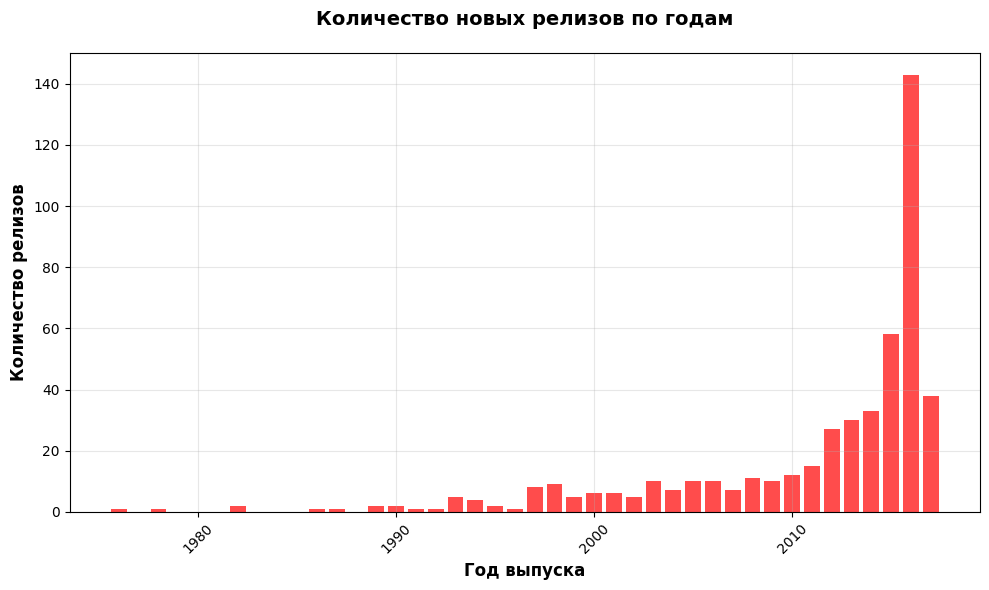

In [ ]:
content_analysis = merge_bd.groupby(['release year', 'rating']).size().unstack(fill_value=0)
rating_strategy = merge_bd['rating'].value_counts()


releases_by_year = merge_bd['release year'].value_counts().sort_index()
releases_by_year = releases_by_year[releases_by_year.index >= 1970]
plt.figure(figsize=(10, 6))
plt.bar(releases_by_year.index, releases_by_year.values, color='red', alpha=0.7)

plt.xlabel('Год выпуска', fontsize=12, fontweight='bold')
plt.ylabel('Количество релизов', fontsize=12, fontweight='bold')
plt.title('Количество новых релизов по годам', fontsize=14, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

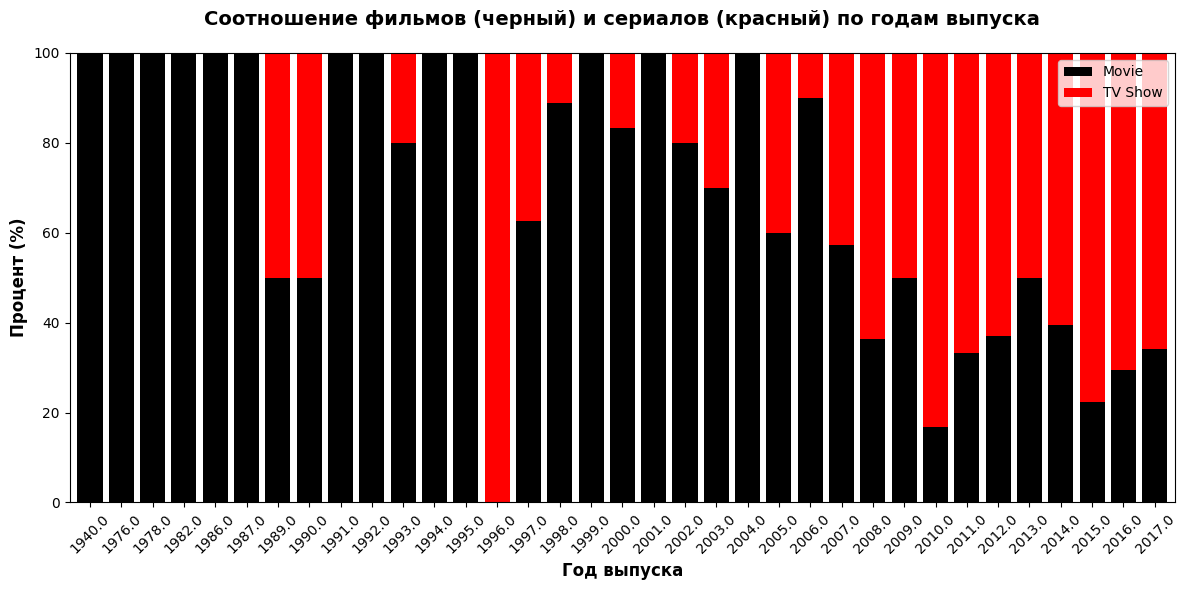

In [ ]:
yearly_counts = merge_bd.groupby(['release year', 'type']).size().unstack(fill_value=0)
yearly_percent = yearly_counts.div(yearly_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = yearly_percent.plot(kind='bar',
                          stacked=True,
                          color=['black', 'red'],
                          ax=ax,
                          width=0.8)

ax.set_xlabel('Год выпуска', fontsize=12, fontweight='bold')
ax.set_ylabel('Процент (%)', fontsize=12, fontweight='bold')
ax.set_title('Соотношение фильмов (черный) и сериалов (красный) по годам выпуска',
             fontsize=14, fontweight='bold', pad=20)

ax.set_ylim(0, 100)
ax.legend(['Movie', 'TV Show'])

plt.xticks(rotation=45)
plt.show()

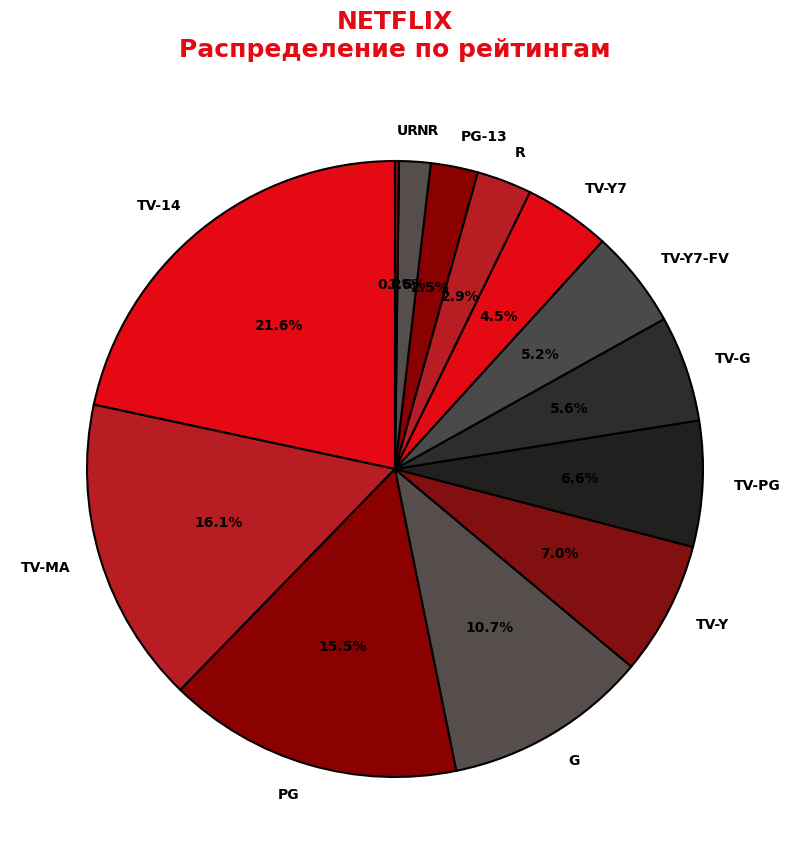

In [ ]:
plt.figure(figsize=(10, 10))

netflix_palette = ['#E50914', '#B81D24', '#8B0000', '#564D4D',
                   '#831010', '#221F1F', '#2D2D2D', '#4A4A4A']

plt.pie(
    merge_bd["rating"].value_counts().values,
    labels=merge_bd["rating"].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=netflix_palette,
    wedgeprops={'edgecolor': '#000000', 'linewidth': 1.5},
    textprops={'color': '#000000', 'fontweight': 'bold', 'fontsize': 10}
)

plt.title('NETFLIX\nРаспределение по рейтингам', fontsize=18, fontweight='bold', color='#E50914', pad=20)

plt.gca().set_facecolor('#FFFFFF')
plt.gcf().set_facecolor('#FFFFFF')

plt.show()

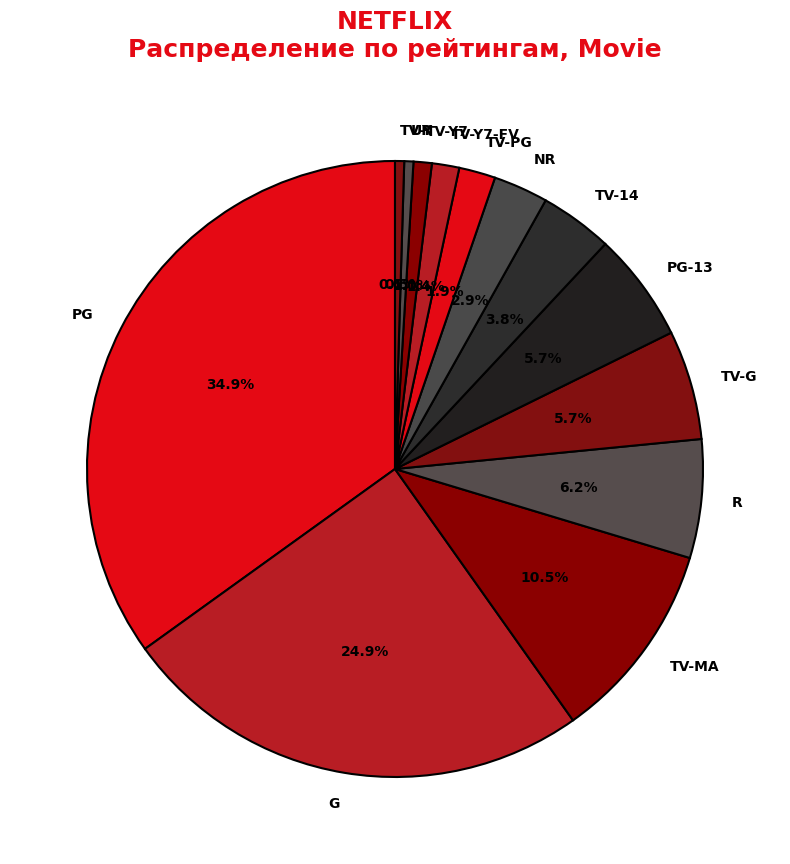

In [ ]:
plt.figure(figsize=(10, 10))

netflix_palette = ['#E50914', '#B81D24', '#8B0000', '#564D4D',
                   '#831010', '#221F1F', '#2D2D2D', '#4A4A4A']

plt.pie(
    merge_bd[merge_bd["type"] == "Movie"]["rating"].value_counts().values,
    labels=merge_bd[merge_bd["type"] == "Movie"]["rating"].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=netflix_palette,
    wedgeprops={'edgecolor': '#000000', 'linewidth': 1.5},
    textprops={'color': '#000000', 'fontweight': 'bold', 'fontsize': 10}
)

plt.title('NETFLIX\nРаспределение по рейтингам, Movie', fontsize=18, fontweight='bold', color='#E50914', pad=20)

plt.gca().set_facecolor('#FFFFFF')
plt.gcf().set_facecolor('#FFFFFF')

plt.show()

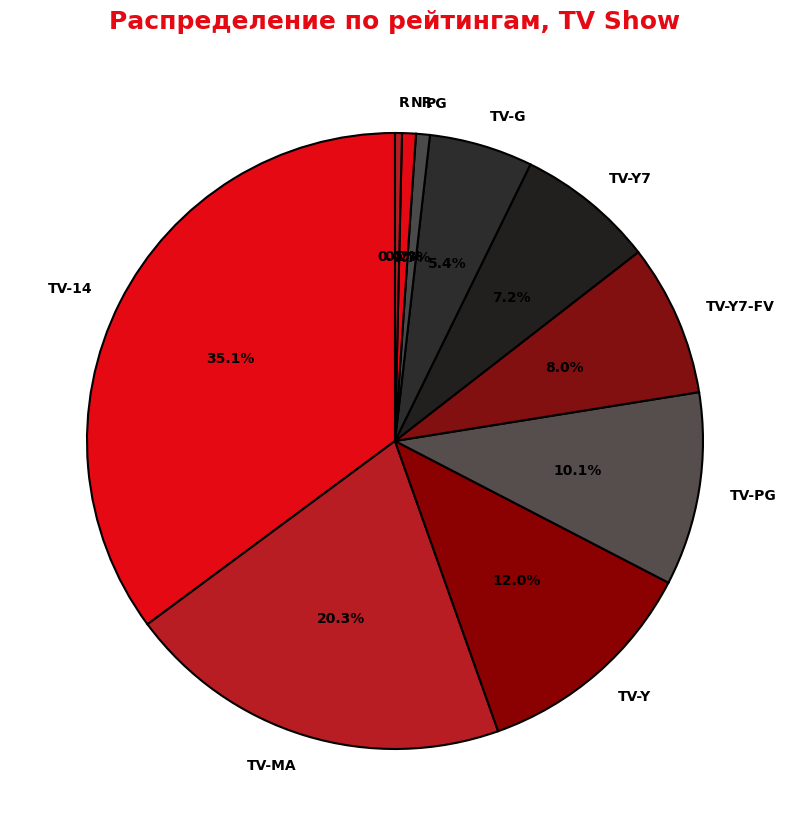

In [ ]:
plt.figure(figsize=(10, 10))

netflix_palette = ['#E50914', '#B81D24', '#8B0000', '#564D4D',
                   '#831010', '#221F1F', '#2D2D2D', '#4A4A4A']

plt.pie(
    merge_bd[merge_bd["type"] == "TV Show"]["rating"].value_counts().values,
    labels=merge_bd[merge_bd["type"] == "TV Show"]["rating"].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=netflix_palette,
    wedgeprops={'edgecolor': '#000000', 'linewidth': 1.5},
    textprops={'color': '#000000', 'fontweight': 'bold', 'fontsize': 10}
)

plt.title('Распределение по рейтингам, TV Show', fontsize=18, fontweight='bold', color='#E50914', pad=20)

plt.gca().set_facecolor('#FFFFFF')
plt.gcf().set_facecolor('#FFFFFF')

plt.show()

* Какие жанры наиболее часто встречаются в библиотеке Netflix?

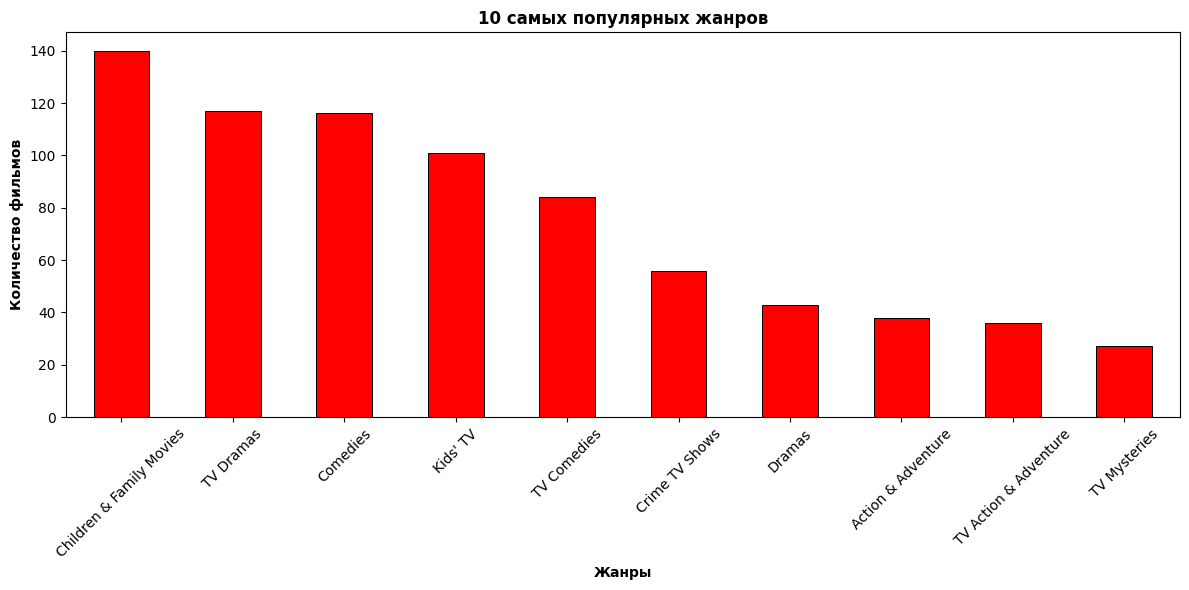

In [ ]:
genres = merge_bd["genres"].dropna().str.split(",").explode().str.strip() # рассматриваем столбец жанров, убираем все NA, сплитим по , возвращаем массив строк, стрип решет строку с отдельных концов
genres1 = genres.value_counts() # считает количество каждого обьекта который получился в таблице
genres1.head(10).plot(kind='bar', figsize=(12, 6), color='red', linewidth = 0.7, edgecolor = 'black')


plt.title('10 самых популярных жанров', fontweight='bold')
plt.xlabel('Жанры', fontweight='bold')
plt.ylabel('Количество фильмов', fontweight='bold')

plt.xticks(rotation=45) # поворот надписей под столбцами

plt.show()

* Есть ли жанры, которые стабильно появляются в топах рейтингов или просмотров?

/tmp/ipython-input-2011139045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  itog['genres'] = itog['genres'].str.split(',')


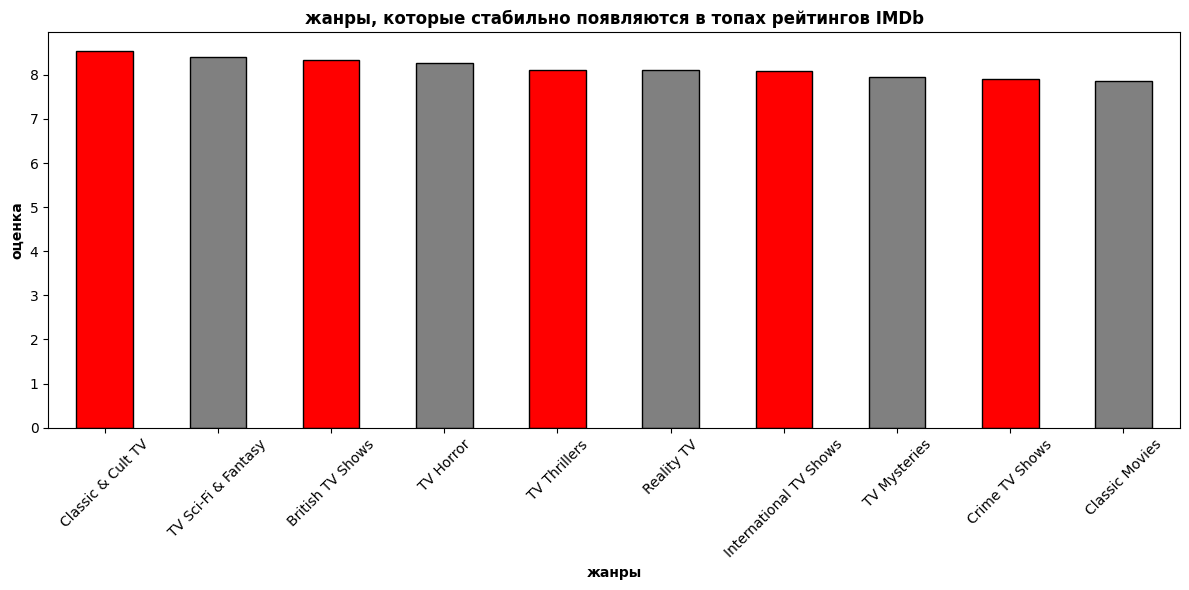

In [ ]:
itog = merge_bd.dropna(subset=['genres', 'imdb_score'])
itog['genres'] = itog['genres'].str.split(',')
itog = itog.explode('genres')
itog['genres'] = itog['genres'].str.strip()

itog1 = itog.groupby(['genres', 'imdb_score']).size()

average_rating = itog.groupby('genres')['imdb_score'].mean() #mean преобразует в среднее

average_rating.sort_values(ascending=False) #без этой штуки не работает (подсмотрела)

top10 = average_rating.nlargest(10)
top10.plot(kind='bar', figsize=(12, 6), color=['red', 'grey'], linewidth = 1, edgecolor = 'black')

plt.title('жанры, которые стабильно появляются в топах рейтингов IMDb', fontweight='bold')

plt.xlabel('жанры', fontweight='bold')

plt.ylabel('оценка', fontweight='bold')

plt.xticks(rotation=45)#поворот надписей под столбцами

plt.show()

* Какой тип контента (Movie / TV Show) чаще получает высокие рейтинги?

/tmp/ipython-input-4237818017.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([movie_ratings, tvshow_ratings],


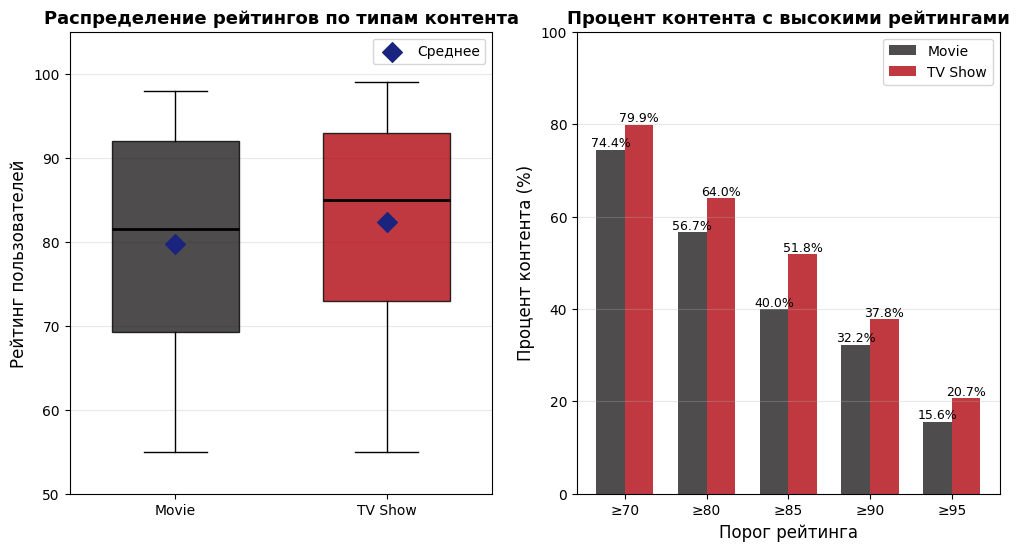

In [ ]:
df_filtered = merge_bd[merge_bd['type'].notna() & merge_bd['user rating score'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# График 1: Box plot
movie_ratings = df_filtered[df_filtered['type'] == 'Movie']['user rating score']
tvshow_ratings = df_filtered[df_filtered['type'] == 'TV Show']['user rating score']

bp = axes[0].boxplot([movie_ratings, tvshow_ratings],
                      labels=['Movie', 'TV Show'],
                      patch_artist=True,
                      widths=0.6,
                      medianprops=dict(color='black', linewidth=2))

colors = ['#221f1f', '#b20710']
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.8)

axes[0].set_ylabel('Рейтинг пользователей', fontsize=12)
axes[0].set_title('Распределение рейтингов по типам контента', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(50, 105)

means = [movie_ratings.mean(), tvshow_ratings.mean()]
axes[0].scatter([1, 2], means, color='#1A237E', s=100, zorder=3, marker='D', label='Среднее')
axes[0].legend()

# График 2: Процент с высокими рейтингами
thresholds = [70, 80, 85, 90, 95]
movie_percentages = []
tvshow_percentages = []

for threshold in thresholds:
    movie_pct = (len(movie_ratings[movie_ratings >= threshold]) / len(movie_ratings)) * 100
    tvshow_pct = (len(tvshow_ratings[tvshow_ratings >= threshold]) / len(tvshow_ratings)) * 100
    movie_percentages.append(movie_pct)
    tvshow_percentages.append(tvshow_pct)

x = np.arange(len(thresholds))
width = 0.35

bars1 = axes[1].bar(x - width/2, movie_percentages, width, label='Movie', color='#221f1f', alpha=0.8)
bars2 = axes[1].bar(x + width/2, tvshow_percentages, width, label='TV Show', color='#b20710', alpha=0.8)

axes[1].set_xlabel('Порог рейтинга', fontsize=12)
axes[1].set_ylabel('Процент контента (%)', fontsize=12)
axes[1].set_title('Процент контента с высокими рейтингами', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'≥{t}' for t in thresholds])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 100)

axes[1].bar_label(bars1, fmt='%.1f%%', fontsize=9)
axes[1].bar_label(bars2, fmt='%.1f%%', fontsize=9)

plt.show()

* Равномерно ли увеличиваются рейтинги по user score и imdb?
* Есть ли зависимость между продолжительностью фильма или серии от рейтинга?
* Сколько времени чаще всего идёт одна серия?

/tmp/ipython-input-1549614357.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
/tmp/ipython-input-1549614357.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()


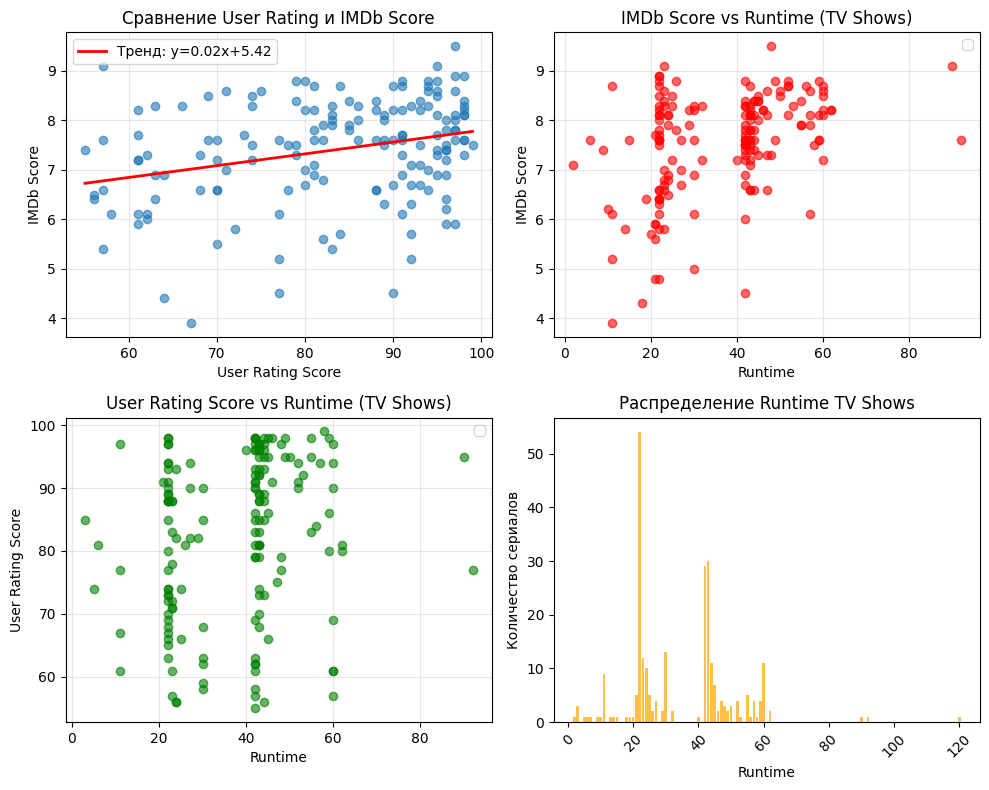

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# График 1: User Rating vs IMDb Score
scores_comparison = merge_bd[["user rating score", "imdb_score"]].dropna()

axes[0,0].scatter(scores_comparison["user rating score"], scores_comparison["imdb_score"], alpha=0.6)

# Линия тренда 1
x = scores_comparison["user rating score"].values
y = scores_comparison["imdb_score"].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
axes[0,0].plot(x_trend, p(x_trend), "r-", linewidth=2, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.2f}')

axes[0,0].set_xlabel("User Rating Score")
axes[0,0].set_ylabel("IMDb Score")
axes[0,0].set_title("Сравнение User Rating и IMDb Score")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# График 2: IMDb Score vs Runtime
series_ratings_imdb = merge_bd[merge_bd["type"] == "TV Show"].dropna(subset=["imdb_score", "runtime"])

axes[0,1].scatter(series_ratings_imdb["runtime"], series_ratings_imdb["imdb_score"], alpha=0.6, color='red')

axes[0,1].set_xlabel("Runtime")
axes[0,1].set_ylabel("IMDb Score")
axes[0,1].set_title("IMDb Score vs Runtime (TV Shows)")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# График 3: User Rating vs Runtime
series_ratings_user = merge_bd[merge_bd["type"] == "TV Show"].dropna(subset=["user rating score", "runtime"])

axes[1,0].scatter(series_ratings_user["runtime"], series_ratings_user["user rating score"], alpha=0.6, color='green')


axes[1,0].set_xlabel("Runtime")
axes[1,0].set_ylabel("User Rating Score")
axes[1,0].set_title("User Rating Score vs Runtime (TV Shows)")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# График 4: Bar chart
runtime_counts_tv = merge_bd[merge_bd["type"] == "TV Show"]["runtime"].dropna().value_counts()
axes[1,1].bar(runtime_counts_tv.index, runtime_counts_tv.values, color='orange', alpha=0.7)
axes[1,1].set_xlabel("Runtime")
axes[1,1].set_ylabel("Количество сериалов")
axes[1,1].set_title("Распределение Runtime TV Shows")
axes[1,1].tick_params(axis='x', rotation=45)

plt.show()

## СОДЕРЖАНИЕ

In [ ]:
actors_imdb = merge_bd.dropna(subset=["imdb_score", "cast"]).copy()
actors_imdb["cast"] = actors_imdb["cast"].str.split(",")
actors_imdb = actors_imdb.explode("cast")
actors_imdb["cast"] = actors_imdb["cast"].str.strip()

actors_imdb = actors_imdb.groupby("cast").agg(count=("cast", "size"), sum_imdb=("imdb_score", "sum"))
actors_imdb["average_rating"] = actors_imdb["sum_imdb"] / actors_imdb["count"]
actors_imdb = actors_imdb.sort_values(by="average_rating", ascending=False)
actors_imdb = actors_imdb[actors_imdb["count"] > 2]
actors_imdb = actors_imdb.sort_values(by="average_rating", ascending=False)
actors_imdb["place"] = actors_imdb["average_rating"].rank(ascending=False)

# список актёров с 3 и более фильмами, оценёнными на imdb, отсортированный по рейтингу

print(actors_imdb)

                          count  sum_imdb  average_rating  place
cast                                                            
Giancarlo Esposito            3      26.5        8.833333    1.0
Miguel Ángel Silvestre        3      25.1        8.366667    2.0
Jonathan Banks                3      25.0        8.333333    3.0
Steven Yeun                   3      24.6        8.200000    4.0
Liza Weil                     3      23.9        7.966667    5.0
Jon Hamm                      3      23.8        7.933333    6.0
Jesse Plemons                 3      23.7        7.900000    7.0
Clancy Brown                  3      22.4        7.466667    8.0
Kevin Michael Richardson      5      37.3        7.460000    9.0
Lucy Liu                      3      22.3        7.433333   10.0
Keith David                   3      21.9        7.300000   11.0
Grey DeLisle                  3      21.1        7.033333   12.0
Johnny Depp                   3      21.0        7.000000   13.0
Catherine O'Hara         

In [ ]:
actors_user_score = merge_bd.dropna(subset=["user rating score", "cast"]).copy()
actors_user_score["cast"] = actors_user_score["cast"].str.split(",")
actors_user_score = actors_user_score.explode("cast")
actors_user_score["cast"] = actors_user_score["cast"].str.strip()

actors_user_score = actors_user_score.groupby("cast").agg(count=("cast", "count"), sum_user_score=("user rating score", "sum"))
actors_user_score["average_rating"] = actors_user_score["sum_user_score"] / actors_user_score["count"]
actors_user_score = actors_user_score.sort_values(by="average_rating", ascending=False)
actors_user_score = actors_user_score[actors_user_score["count"] > 2]
actors_user_score = actors_user_score.sort_values(by="average_rating", ascending=False)
actors_user_score["place"] = actors_user_score["average_rating"].rank(ascending=False)

# список актёров с 3 и более фильмами, оценёнными по user_score, отсортированный по рейтингу

print(actors_user_score)

                          count  sum_user_score  average_rating  place
cast                                                                  
Kate Walsh                    3           285.0       95.000000    1.0
Patrick Warburton             4           379.0       94.750000    2.0
Bill Hader                    3           280.0       93.333333    3.0
Seth Rogen                    3           274.0       91.333333    4.0
Giancarlo Esposito            3           272.0       90.666667    5.5
David Spade                   3           272.0       90.666667    5.5
Kathy Bates                   3           266.0       88.666667    7.0
Johnny Depp                   3           265.0       88.333333    8.0
Adam Sandler                  4           351.0       87.750000    9.0
John Goodman                  3           263.0       87.666667   10.5
Liza Weil                     3           263.0       87.666667   10.5
Matt Bomer                    3           260.0       86.666667   12.0
Jon Ha

In [ ]:
merged_actors = pd.merge(actors_imdb[["average_rating", "place"]], actors_user_score[["average_rating", "place"]], left_index=True, right_index=True)
merged_actors["sum_places"] = merged_actors["place_x"] + merged_actors["place_y"]
merged_actors = merged_actors.sort_values(by="sum_places")

# пересечение двух таблиц выше с суммированием мест из них

print(merged_actors)

                          average_rating_x  place_x  average_rating_y  \
cast                                                                    
Giancarlo Esposito                8.833333      1.0         90.666667   
Liza Weil                         7.966667      5.0         87.666667   
Jon Hamm                          7.933333      6.0         83.666667   
Seth Rogen                        6.933333     16.0         91.333333   
Bill Hader                        6.833333     18.0         93.333333   
Johnny Depp                       7.000000     13.0         88.333333   
Catherine O'Hara                  6.966667     14.0         83.333333   
Clancy Brown                      7.466667      8.0         77.333333   
Lucy Liu                          7.433333     10.0         80.000000   
Kevin Michael Richardson          7.460000      9.0         74.333333   
Laraine Newman                    6.900000     17.0         77.666667   
Grey DeLisle                      7.033333     12.0

In [ ]:
actors = merge_bd["cast"].dropna().str.split(",").explode().str.strip()
top_actors = actors.value_counts()

# количество фильмов/шоу, в которых снимались актёры

print(top_actors)

cast
NOINFO                      68
Jim Cummings                 8
Kevin Michael Richardson     8
Fred Tatasciore              7
Dee Bradley Baker            7
                            ..
Iretiola Doyle               1
Devin Druid                  1
Ross Butler                  1
Christian Navarro            1
Alisha Boe                   1
Name: count, Length: 2538, dtype: int64


In [ ]:
genres = merge_bd["genres"].dropna().str.split(",").explode().str.strip()
genres = genres.value_counts()

genres_imdb = merge_bd.dropna(subset=["imdb_score", "genres"]).copy()
genres_imdb["genres"] = genres_imdb["genres"].str.split(",")
genres_imdb = genres_imdb.explode("genres")
genres_imdb["genres"] = genres_imdb["genres"].str.strip()

genres_imdb = genres_imdb.groupby("genres").agg(count=("genres", "count"), sum_imdb=("imdb_score", "sum"))
genres_imdb["average_rating"] = genres_imdb["sum_imdb"] / genres_imdb["count"]
genres_imdb = genres_imdb.sort_values(by="average_rating")
genres_imdb = genres_imdb[genres_imdb["count"] > 7]
genres_imdb["place"] = genres_imdb["average_rating"].rank(ascending=False)

# аналогично актёрам, но по жанрам

print(genres_imdb)

                          count  sum_imdb  average_rating  place
genres                                                          
Comedies                     53     324.9        6.130189   20.0
Independent Movies           11      69.3        6.300000   19.0
Romantic Movies              10      63.9        6.390000   18.0
Children & Family Movies     54     347.9        6.442593   17.0
Dramas                       23     148.7        6.465217   16.0
Action & Adventure           22     145.8        6.627273   15.0
Kids' TV                     46     309.7        6.732609   14.0
Sci-Fi & Fantasy             11      74.4        6.763636   13.0
Music & Musicals              9      61.7        6.855556   12.0
Teen TV Shows                 9      65.7        7.300000   11.0
TV Comedies                  52     387.7        7.455769   10.0
TV Sci-Fi & Fantasy          15     112.1        7.473333    9.0
Romantic TV Shows            13      98.5        7.576923    8.0
TV Action & Adventure    

In [ ]:
genres_user_score = merge_bd.dropna(subset=["user rating score", "genres"]).copy()
genres_user_score["genres"] = genres_user_score["genres"].str.split(",")
genres_user_score = genres_user_score.explode("genres")
genres_user_score["genres"] = genres_user_score["genres"].str.strip()

genres_user_score = genres_user_score.groupby("genres").agg(count=("genres", "count"), sum_user_score=("user rating score", "sum"))
genres_user_score["average_rating"] = genres_user_score["sum_user_score"] / genres_user_score["count"]
genres_user_score = genres_user_score.sort_values(by="average_rating", ascending=False)
genres_user_score = genres_user_score[genres_user_score["count"] > 7]
genres_user_score["place"] = genres_user_score["average_rating"].rank(ascending=False)

# аналогично актёрам, но по жанрам

print(genres_user_score)

                          count  sum_user_score  average_rating  place
genres                                                                
Romantic TV Shows            11           963.0       87.545455    1.0
Crime TV Shows               46          4010.0       87.173913    2.0
TV Thrillers                  9           783.0       87.000000    3.0
TV Mysteries                 22          1909.0       86.772727    4.0
Action & Adventure           24          2045.0       85.208333    5.0
TV Action & Adventure        26          2203.0       84.730769    6.0
TV Dramas                    89          7472.0       83.955056    7.0
Sci-Fi & Fantasy             16          1340.0       83.750000    8.0
International TV Shows       12          1003.0       83.583333    9.0
TV Sci-Fi & Fantasy          14          1148.0       82.000000   10.0
British TV Shows              8           651.0       81.375000   11.0
TV Comedies                  51          4126.0       80.901961   12.0
Comedi

In [ ]:
merged_genres = pd.merge(genres_imdb[["average_rating", "place"]], genres_user_score[["average_rating", "place"]], left_index=True, right_index=True)
merged_genres["sum_places"] = merged_genres["place_x"] + merged_genres["place_y"]
merged_genres = merged_genres.sort_values(by="sum_places")

# аналогично актёрам, но по жанрам

print(merged_genres)

                          average_rating_x  place_x  average_rating_y  \
genres                                                                  
TV Thrillers                      8.111111      2.0         87.000000   
Crime TV Shows                    7.895238      5.0         87.173913   
TV Mysteries                      7.947368      4.0         86.772727   
Romantic TV Shows                 7.576923      8.0         87.545455   
International TV Shows            8.080000      3.0         83.583333   
British TV Shows                  8.325000      1.0         81.375000   
TV Action & Adventure             7.786364      7.0         84.730769   
TV Dramas                         7.839759      6.0         83.955056   
TV Sci-Fi & Fantasy               7.473333      9.0         82.000000   
Action & Adventure                6.627273     15.0         85.208333   
Sci-Fi & Fantasy                  6.763636     13.0         83.750000   
TV Comedies                       7.455769     10.0

## ПРОДОЛЖИТЕЛЬНОСТЬ

* Как связана продолжительность фильма (или количество сезонов) с его рейтингом?

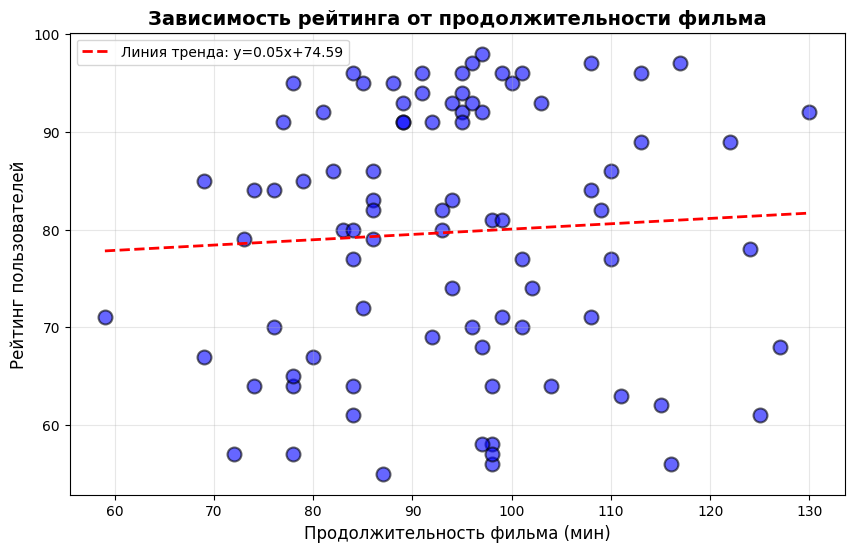

In [ ]:
movies_data = merge_bd[merge_bd['type'] == 'Movie'].copy()

movies_analysis_data = movies_data[movies_data['runtime'].notna() & movies_data['user rating score'].notna()].copy()

plt.figure(figsize=(10, 6))

plt.scatter(movies_analysis_data['runtime'], movies_analysis_data['user rating score'],
            alpha=0.6, s=100, color='blue', edgecolors='black', linewidth=1.5)

x = movies_analysis_data['runtime'].values
y = movies_analysis_data['user rating score'].values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Линия тренда: y={z[0]:.2f}x+{z[1]:.2f}')

plt.xlabel('Продолжительность фильма (мин)', fontsize=12)
plt.ylabel('Рейтинг пользователей', fontsize=12)
plt.title('Зависимость рейтинга от продолжительности фильма', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

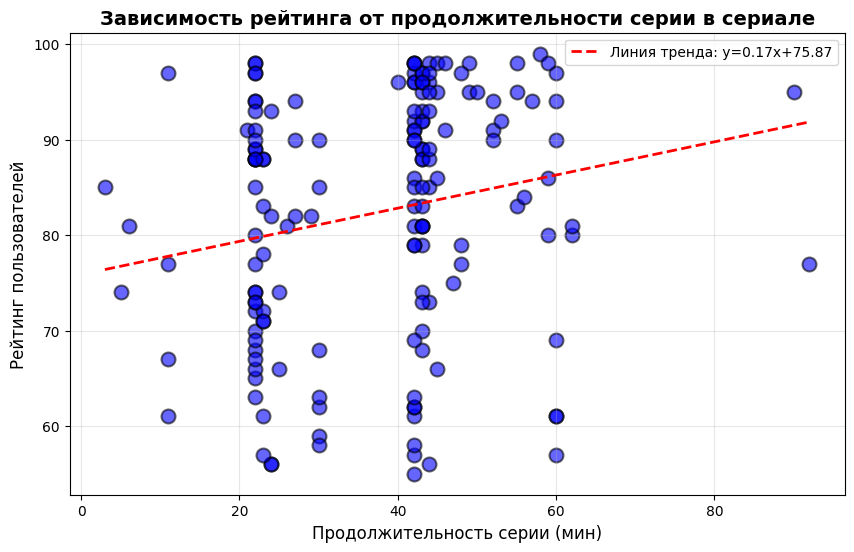

In [ ]:
tvshow_df = merge_bd[merge_bd['type'] == 'TV Show'].copy()

tvshow_analysis = tvshow_df[tvshow_df['runtime'].notna() & tvshow_df['user rating score'].notna()].copy()

plt.figure(figsize=(10, 6))

plt.scatter(tvshow_analysis['runtime'], tvshow_analysis['user rating score'],
            alpha=0.6, s=100, color='blue', edgecolors='black', linewidth=1.5)

x = tvshow_analysis['runtime'].values
y = tvshow_analysis['user rating score'].values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Линия тренда: y={z[0]:.2f}x+{z[1]:.2f}')

plt.xlabel('Продолжительность серии (мин)', fontsize=12)
plt.ylabel('Рейтинг пользователей', fontsize=12)
plt.title('Зависимость рейтинга от продолжительности серии в сериале', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

* Сколько в среднем идут фильмы/шоу в каждом жанре

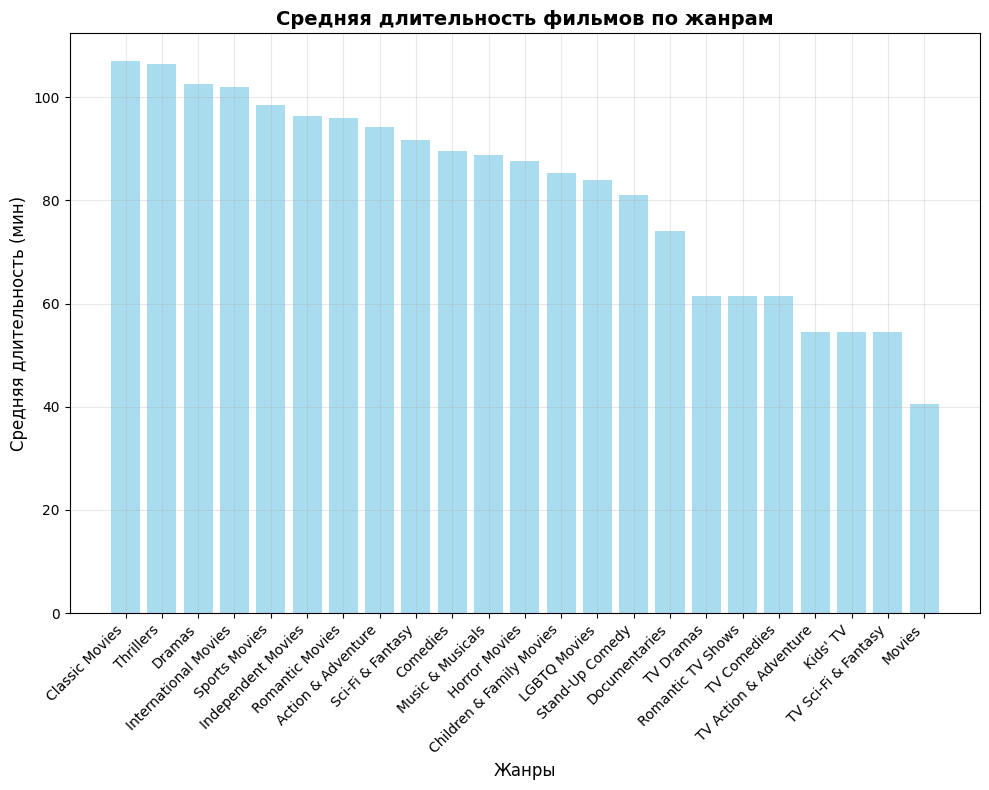

In [ ]:
merge_bd['genres_list'] = merge_bd['genres'].str.split(', ')
movies_data = merge_bd[merge_bd['type'] == 'Movie'].explode('genres_list')
movies_clean = movies_data.dropna(subset=['runtime', 'genres_list'])

# Все жанры
all_genres_movies = movies_clean['genres_list'].value_counts().index

plt.figure(figsize=(10, 8))

# График: Средняя длительность по всем жанрам (фильмы)
genre_runtime_avg = movies_clean.groupby('genres_list')['runtime'].mean().sort_values(ascending=False)
plt.bar(genre_runtime_avg.index, genre_runtime_avg.values, color='skyblue', alpha=0.7)
plt.xlabel("Жанры", fontsize=12)
plt.ylabel("Средняя длительность (мин)", fontsize=12)
plt.title("Средняя длительность фильмов по жанрам", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.show()

* Как изменяется средняя длительность фильмов с годами?

Text(0, 0.5, 'Средняя длительность (мин)')

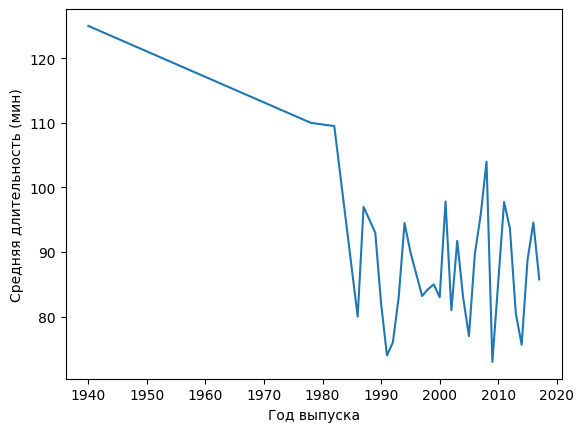

In [ ]:
movies_data = merge_bd[merge_bd['type'] == 'Movie']
movies_clean = movies_data.dropna(subset=['runtime', 'release year'])

duration_by_year = movies_clean.groupby('release year')['runtime'].mean()

plt.plot(duration_by_year.index, duration_by_year.values)
plt.xlabel("Год выпуска")
plt.ylabel("Средняя длительность (мин)")

* Как изменяется средняя длительность сериалов с годами?

Text(0, 0.5, 'Средняя длительность (мин)')

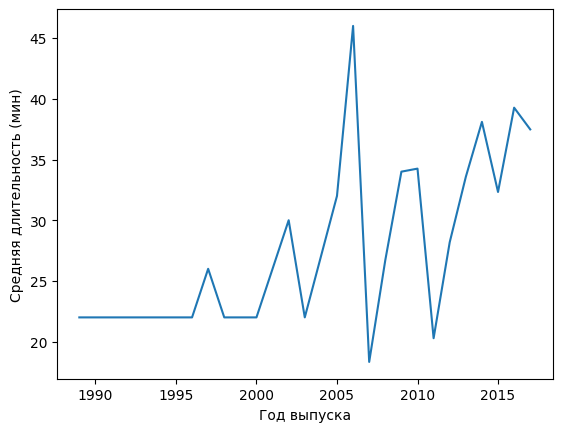

In [ ]:
movies_data = merge_bd[merge_bd['type'] == 'TV Show']
movies_clean = movies_data.dropna(subset=['runtime', 'release year'])

duration_by_year = movies_clean.groupby('release year')['runtime'].mean()

plt.plot(duration_by_year.index, duration_by_year.values)
plt.xlabel("Год выпуска")
plt.ylabel("Средняя длительность (мин)")

ГЕОГРАФИЯ И РЫНОК
-----------------------------------
Мини цель: нам нужно понять, куда выгодно инвестировать в локальный контент
* Какие страны производят наибольшее количество контента для Netflix?
* Есть ли различия в рейтингах фильмов/шоу по странам?
* Какие регионы чаще производят фильмы/шоу определённых жанров?



* Какие страны производят наибольшее количество контента для Netflix?

In [ ]:
countries_count = merge_bd.dropna(subset=["country"]).copy()
countries_count["country"] = countries_count["country"].str.split(",")
countries_count = countries_count.explode("country")
countries_count["country"] = countries_count["country"].str.strip()
shows_by_country = countries_count["country"].value_counts()

print(shows_by_country.head)

<bound method NDFrame.head of country
United States     373
Canada             44
United Kingdom     33
France             19
NOINFO             15
Japan              13
Belgium             8
Australia           8
Spain               8
Brazil              7
India               7
Germany             5
Ireland             5
South Korea         5
Italy               5
Finland             4
Mexico              3
Luxembourg          3
China               3
Denmark             3
Russia              2
Hong Kong           2
Cyprus              1
Thailand            1
Egypt               1
Colombia            1
Malaysia            1
Netherlands         1
Singapore           1
Turkey              1
Portugal            1
Nigeria             1
Argentina           1
Name: count, dtype: int64>


* Какие различия в средних рейтингах фильмов и сериалов по странам?

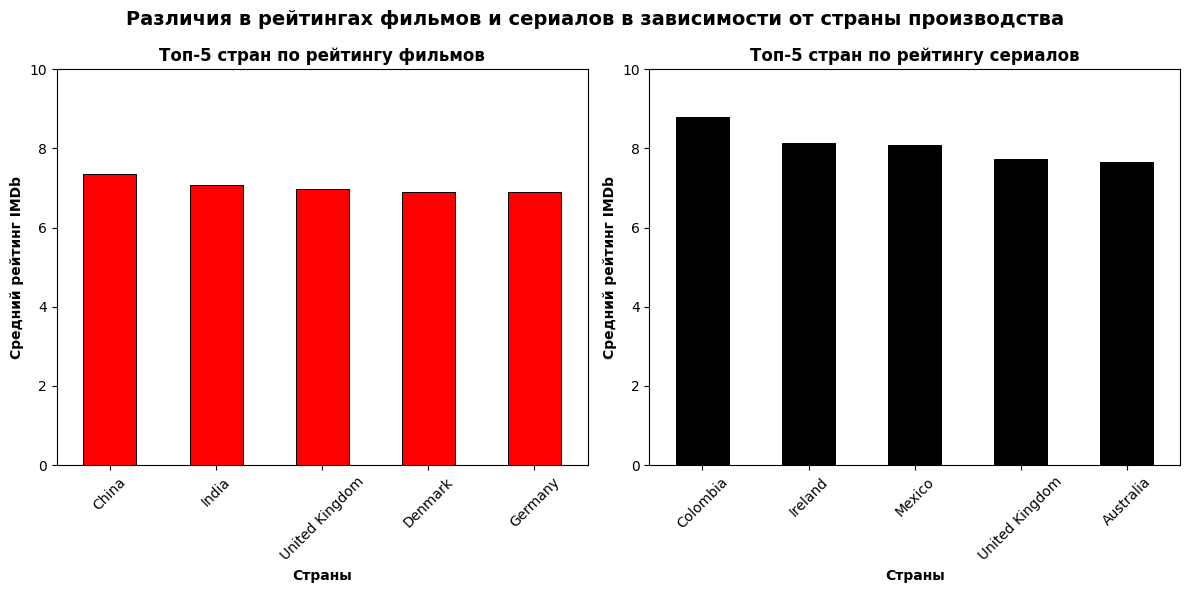

In [ ]:
countrys = merge_bd["country"].dropna().str.split(",").explode().str.strip() #рассматриваем столбец стран, убираем все NA, сплитим по , возвращаем массив строк, стрип решет строку с отдельных концов
countrys1 = countrys.value_counts() #считает количество каждого обьекта который получился в таблице

itog = merge_bd.dropna(subset=['country', 'type', 'imdb_score']).copy()

itog['country'] = itog['country'].str.split(',')
itog = itog.explode('country')
itog['country'] = itog['country'].str.strip()

itog1 = itog.groupby(['country', 'type'])['imdb_score'].mean()

#смотрим на средний рейтинг (imdb) tv show и movie в кадой стране отдельно

movies_top = itog1[:, 'Movie'].sort_values(ascending=False).head(5)

tv_top = itog1[:, 'TV Show'].sort_values(ascending=False).head(5)
plt.figure(figsize=(12,3))
plt.suptitle('Различия в рейтингах фильмов и сериалов в зависимости от страны производства', fontweight='bold', fontsize=14)
plt.subplot(1,2,1)


movies_top.plot(kind='bar', figsize=(12, 6), color='red', linewidth = 0.7, edgecolor = 'black')
plt.title('Топ-5 стран по рейтингу фильмов', fontweight='bold')
plt.xlabel('Страны', fontweight='bold')
plt.xticks(rotation=45)#поворот надписей под столбцами
plt.ylabel('Средний рейтинг IMDb', fontweight='bold')
plt.ylim(0, 10)

plt.subplot(1,2,2)

tv_top.plot(kind = 'bar', figsize=(12, 6), color='black', linewidth = 0.7, edgecolor = 'black')
plt.xticks(rotation=45)#поворот надписей под столбцами

plt.title('Топ-5 стран по рейтингу сериалов', fontweight='bold')

plt.xlabel('Страны', fontweight='bold')
plt.ylabel('Средний рейтинг IMDb', fontweight='bold')

plt.ylim(0, 10)
plt.tight_layout() # корректирует расположение подграфиков
plt.show()

* Есть ли различия в рейтингах фильмов/шоу по странам?

In [ ]:
countries_imdb = merge_bd.dropna(subset=["imdb_score", "country"]).copy()
countries_imdb["country"] = countries_imdb["country"].str.split(",")
countries_imdb = countries_imdb.explode("country")
countries_imdb["country"] = countries_imdb["country"].str.strip()

countries_imdb = countries_imdb.groupby("country").agg(count=("country", "count"), sum_imdb=("imdb_score", "sum"))
countries_imdb["average_rating"] = countries_imdb["sum_imdb"] / countries_imdb["count"]
countries_imdb = countries_imdb.sort_values(by="average_rating")
countries_imdb = countries_imdb[countries_imdb["count"] > 5]

# аналогично актёрам, но по странам

print(countries_imdb)

                count  sum_imdb  average_rating
country                                        
Spain               6      37.0        6.166667
Canada             27     183.5        6.796296
Japan               7      49.2        7.028571
France             10      70.5        7.050000
United States     206    1472.9        7.150000
United Kingdom     21     158.1        7.528571


In [ ]:
countries_user_score = merge_bd.dropna(subset=["user rating score", "country"]).copy()
countries_user_score["country"] = countries_user_score["country"].str.split(",")
countries_user_score = countries_user_score.explode("country")
countries_user_score["country"] = countries_user_score["country"].str.strip()

countries_user_score = countries_user_score.groupby("country").agg(count=("country", "count"), sum_user_score=("user rating score", "sum"))
countries_user_score["average_rating"] = countries_user_score["sum_user_score"] / countries_user_score["count"]
countries_user_score = countries_user_score.sort_values(by="average_rating")
countries_user_score = countries_user_score[countries_user_score["count"] > 5]

# аналогично актёрам, но по странам

print(countries_user_score)

                count  sum_user_score  average_rating
country                                              
France              6           467.0       77.833333
United Kingdom     14          1117.0       79.785714
Canada             17          1376.0       80.941176
United States     226         18524.0       81.964602


* Какие регионы чаще производят фильмы/шоу определённых жанров?

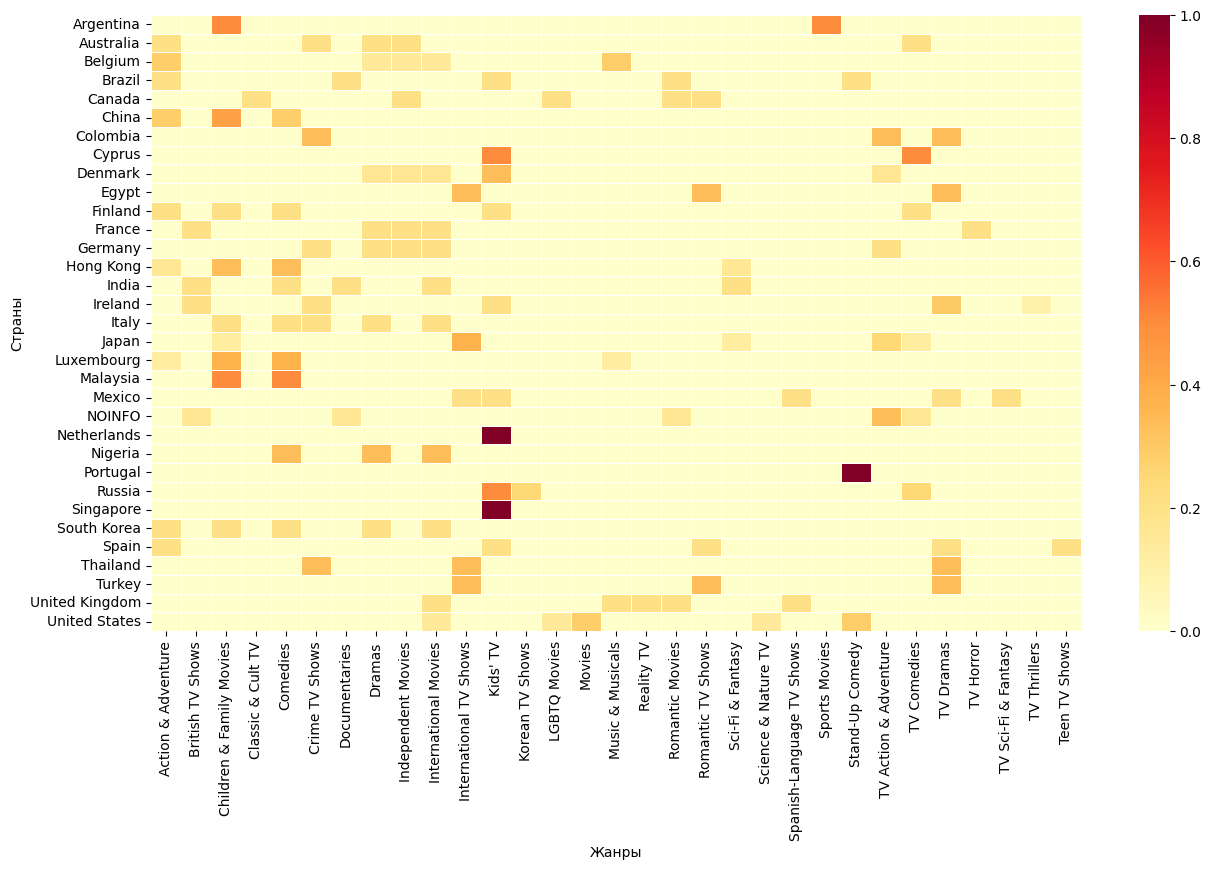

In [ ]:
countries_categories = merge_bd.dropna(subset=["genres", "country"]).copy()
countries_categories["genres"] = countries_categories["genres"].str.split(",")
countries_categories["country"] = countries_categories["country"].str.split(",")
countries_categories = countries_categories.explode("genres").explode("country")

countries_categories["genres"] = countries_categories["genres"].str.strip()
countries_categories["country"] = countries_categories["country"].str.strip()

countries_categories = countries_categories.groupby(["country", "genres"]).size().reset_index(name="count")

countries_categories["rank"] = countries_categories.groupby("country")["count"].rank(method="first")
top5_genres_by_country = countries_categories[countries_categories["rank"] <= 5].sort_values(["country", "rank"])

pivot = top5_genres_by_country.pivot(index="country", columns="genres", values="count").fillna(0)

pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_norm, cmap="YlOrRd", linewidths=0.5)
plt.xlabel("Жанры")
plt.ylabel("Страны")
plt.show()

## ИЗМЕНЕНИЯ СО ВРЕМЕНЕМ

* Как изменяется количество фильмов разных рейтингов с течением времени?

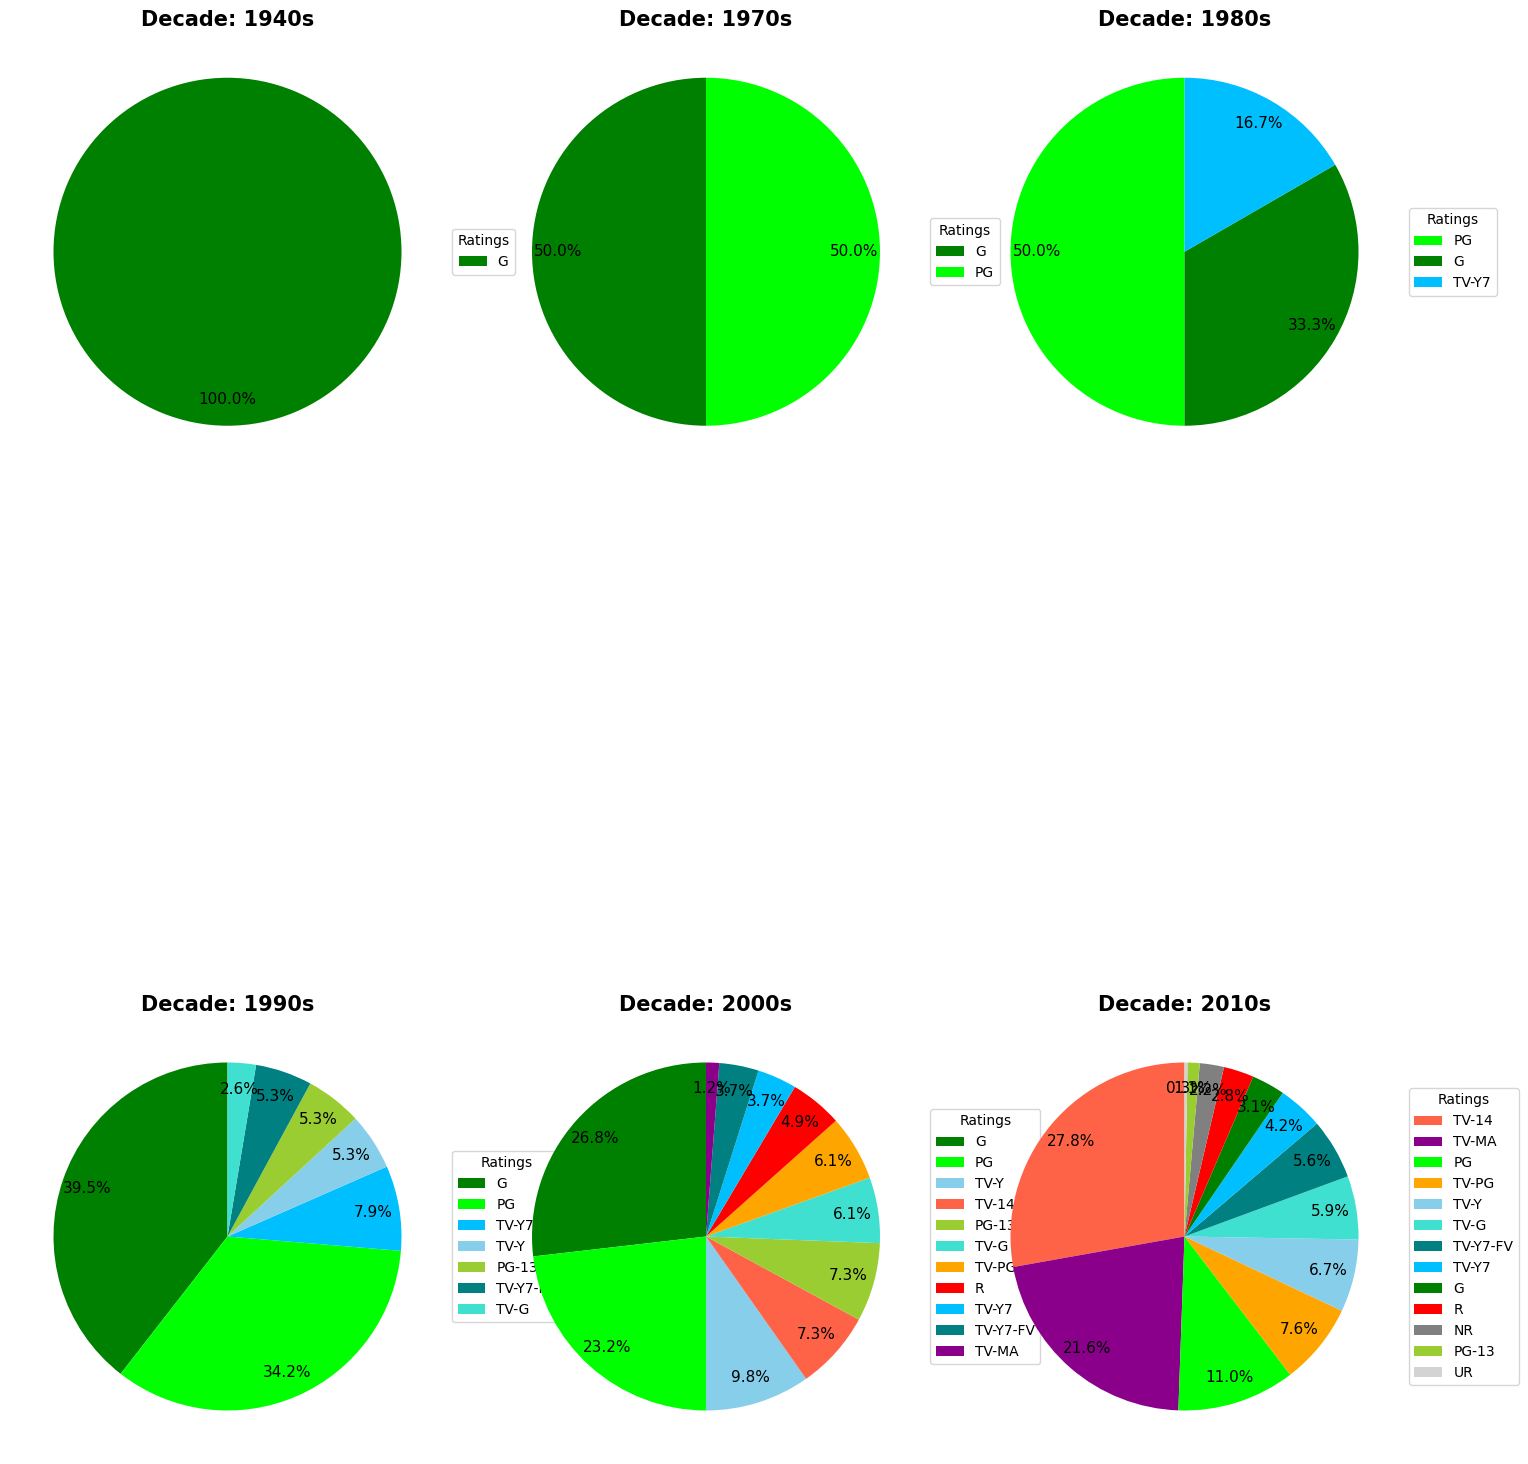

In [ ]:
ах# Подготовка данных
merged_with_decade = merge_bd.dropna(subset=["release year", "rating"]).copy()
merged_with_decade["decade"] = (merged_with_decade["release year"] // 10) * 10

# Цвета для рейтингов
rating_colors = {
    'G': 'green',
    'PG': 'lime',
    'PG-13': 'yellowgreen',
    'R': 'red',
    'NC-17': 'darkred',
    'TV-Y': 'skyblue',
    'TV-Y7': 'deepskyblue',
    'TV-Y7-FV': 'teal',
    'TV-G': 'turquoise',
    'TV-PG': 'orange',
    'TV-14': 'tomato',
    'TV-MA': 'darkmagenta',
    'NR': 'gray',
    'UR': 'lightgray'
}

# Создаём сетку 3x2 (3 строки, 2 столбца) с увеличенным размером
fig, axes = plt.subplots(2, 3, figsize=(16, 20))
axes = axes.flatten()  # Преобразуем в одномерный массив

# Получаем отсортированные декады
decades = sorted(merged_with_decade['decade'].unique())

# Рисуем диаграмму для каждой декады
for idx, decade in enumerate(decades):
    tmp = merged_with_decade[merged_with_decade['decade'] == decade]
    counts = tmp['rating'].value_counts()

    if counts.empty:
        continue

    colors = [rating_colors.get(r, 'lightgray') for r in counts.index]

    # Рисуем круговые диаграммы
    wedges, texts, autotexts = axes[idx].pie(
        counts.values,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 11},
        pctdistance=0.85
    )

    # Легенда
    axes[idx].legend(wedges, counts.index,
                     title="Ratings",
                     loc="center left",
                     bbox_to_anchor=(1, 0.5),
                     fontsize=10)

    axes[idx].set_title(f"Decade: {int(decade)}s", fontsize=15, fontweight='bold')


plt.subplots_adjust(left=0.03, right=0.9, top=0.97, bottom=0.03,
                    hspace=0.1, wspace=0.1)

plt.show()

* Как меняются рейтинги фильмов/шоу с течением времени?

In [ ]:
акrating_years_user_score = merge_bd.dropna(subset=["release year", "imdb_score"]).copy()
rating_years_user_score["decade"] = (rating_years_user_score["release year"] // 10) * 10
decade_ratings_user_score = rating_years_user_score.groupby("decade").agg(average_rating=("imdb_score", "mean"),count=("imdb_score", "size"))
decade_ratings_user_score = decade_ratings_user_score[decade_ratings_user_score["count"] > 4]
print(decade_ratings_user_score)

# средний рейтинг всех imdb фильмов/шоу по декадам и их количество

        average_rating  count
decade                       
1990.0        6.726667     15
2000.0        6.597500     40
2010.0        7.234634    205


In [ ]:
rating_years_imdb = merge_bd.dropna(subset=["release year", "user rating score"]).copy()
rating_years_imdb["decade"] = (rating_years_imdb["release year"] // 10) * 10
decade_ratings_imdb = rating_years_imdb.groupby("decade").agg(average_rating=("user rating score", "mean"),count=("user rating score", "size"))
decade_ratings_imdb = decade_ratings_imdb[decade_ratings_imdb["count"] > 4]
print(decade_ratings_imdb)

# средний рейтинг всех user_score фильмов/шоу по декадам и их количество

        average_rating  count
decade                       
1990.0       78.791667     24
2000.0       79.068182     44
2010.0       82.750000    180


/tmp/ipython-input-2843280691.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(movie_counts.index,


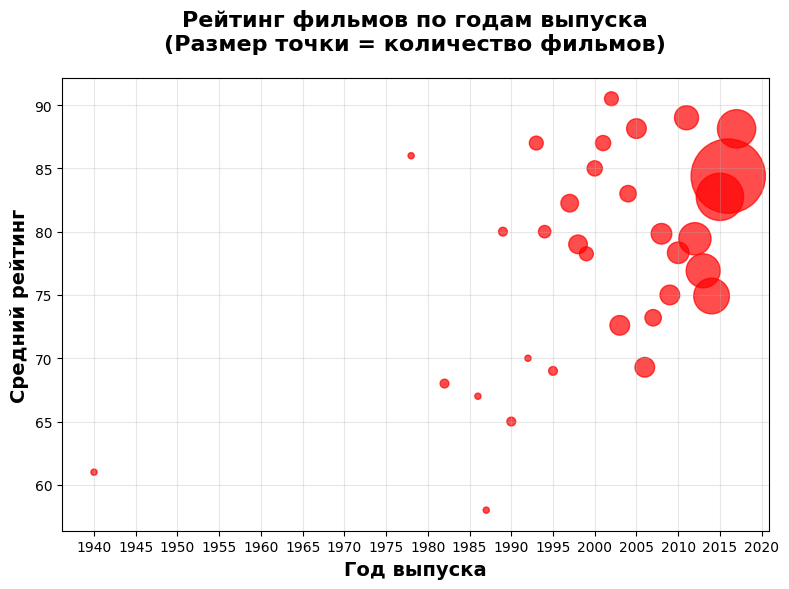

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

movie_counts = merge_bd.groupby('release year').size()

scatter = ax.scatter(movie_counts.index,
                    merge_bd.groupby('release year')['user rating score'].mean(),
                    s=movie_counts.values * 20,
                    alpha=0.7,
                    color='red',
                    cmap='red')

ax.set_xlabel('Год выпуска', fontsize=14, fontweight='bold')
ax.set_ylabel('Средний рейтинг', fontsize=14, fontweight='bold')
ax.set_title('Рейтинг фильмов по годам выпуска\n(Размер точки = количество фильмов)',
             fontsize=16, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))  # сетка каждые 5 лет
ax.yaxis.set_major_locator(plt.MultipleLocator(5))  # сетка каждые 5 баллов
plt.tight_layout()
plt.show()

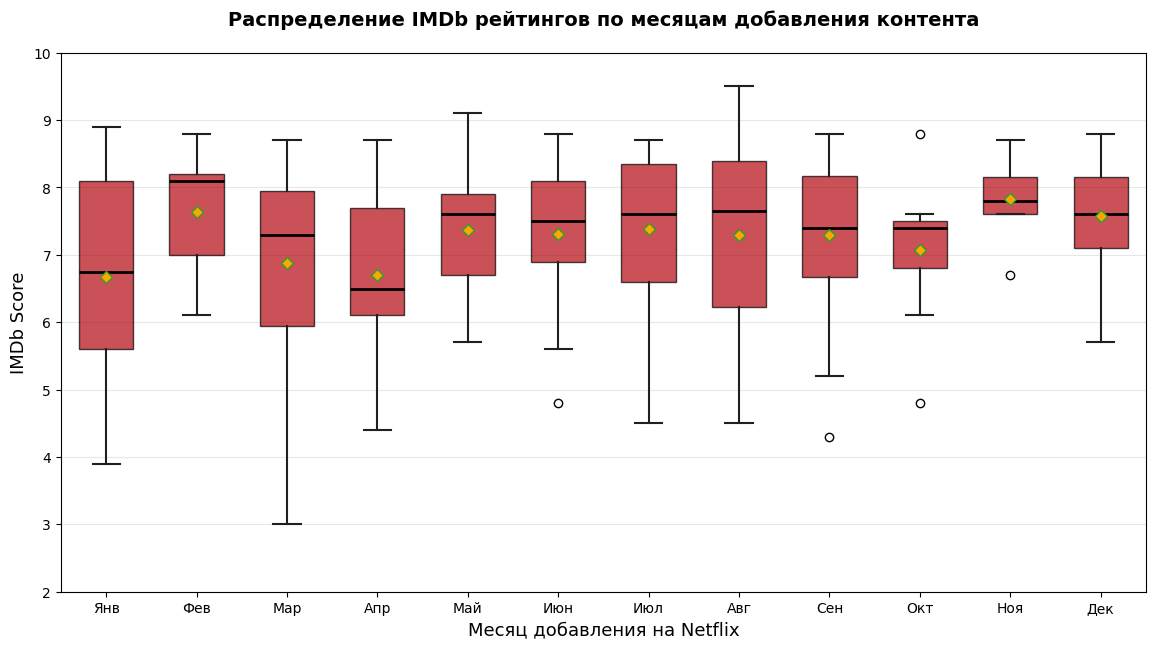

In [ ]:
date_added_imdb = merge_bd.dropna(subset=["date_added", "imdb_score"]).copy()
date_added_imdb['date_added'] = date_added_imdb['date_added'].astype(str).str.strip()
date_added_imdb['date_added'] = pd.to_datetime(date_added_imdb['date_added'])
date_added_imdb['month_added'] = date_added_imdb['date_added'].dt.month

# Подготовка данных для боксплотов - группируем по месяцам
data_by_month = [date_added_imdb[date_added_imdb['month_added'] == month]['imdb_score'].values
                 for month in range(1, 13)]

# Создаём боксплоты
fig, ax = plt.subplots(figsize=(14, 7))

bp = ax.boxplot(data_by_month,
                positions=range(1, 13),
                widths=0.6,
                patch_artist=True,  # Позволяет раскрашивать боксы
                showmeans=True,     # Показывает среднее значение
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='orange', markersize=6),
                boxprops=dict(facecolor='#b20710', alpha=0.7),
                whiskerprops=dict(color='#221f1f', linewidth=1.5),
                capprops=dict(color='#221f1f', linewidth=1.5))

# Названия месяцев
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

# Оформление
ax.set_xlabel('Месяц добавления на Netflix', fontsize=13)
ax.set_ylabel('IMDb Score', fontsize=13)
ax.set_title('Распределение IMDb рейтингов по месяцам добавления контента',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(2, 10)

plt.show()

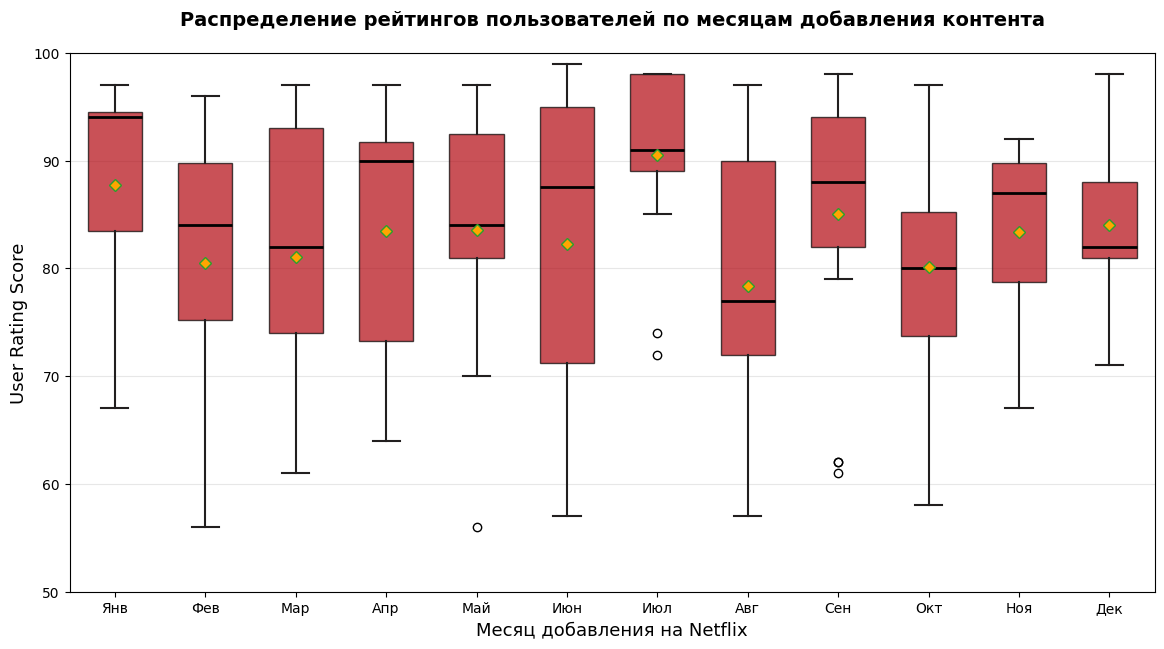

In [ ]:
date_added_score= merge_bd.dropna(subset=["date_added", "user rating score"]).copy()
date_added_score['date_added'] = date_added_score['date_added'].astype(str).str.strip()
date_added_score['date_added'] = pd.to_datetime(date_added_score['date_added'])
date_added_score['month_added'] = date_added_score['date_added'].dt.month

# Создаём список данных только для месяцев, где есть данные
months_with_data = sorted(date_added_score['month_added'].unique())
data_by_month = []
labels = []

for month in months_with_data:
    month_data = date_added_score[date_added_score['month_added'] == month]['user rating score'].values
    data_by_month.append(month_data)

    month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                   'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    labels.append(month_names[month-1])

# Боксплоты
fig, ax = plt.subplots(figsize=(14, 7))

if len(data_by_month) > 0:
    bp = ax.boxplot(data_by_month,
                    positions=months_with_data,
                    widths=0.6,
                    patch_artist=True,
                    showmeans=True,
                    medianprops=dict(color='black', linewidth=2),
                    meanprops=dict(marker='D', markerfacecolor='orange', markersize=6),
                    boxprops=dict(facecolor='#b20710', alpha=0.7),
                    whiskerprops=dict(color='#221f1f', linewidth=1.5),
                    capprops=dict(color='#221f1f', linewidth=1.5))

    # Оформление
    ax.set_xlabel('Месяц добавления на Netflix', fontsize=13)
    ax.set_ylabel('User Rating Score', fontsize=13)
    ax.set_title('Распределение рейтингов пользователей по месяцам добавления контента',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(months_with_data)
    ax.set_xticklabels(labels)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(50, 100)

plt.show()